# ĐỒ ÁN MÁY HỌC - BÀI TẬP LỚN\n
\n
**Sinh viên thực hiện:** Hoàng Ngọc Long  \n
**MSSV:** 22001608  \n
\n
---\n
\n
## MỤC LỤC\n
\n
### PHẦN 1: K-NEAREST NEIGHBORS (KNN) - HỒI QUY VÀ PHÂN LOẠI (GIỮA KỲ)\n
1. Load và Khám phá Dữ liệu\n
2. Phân tích và Trực quan hóa Dữ liệu\n
3. Hồi quy KNN\n
4. Phân loại KNN\n
5. Tổng kết và Nhận xét\n
\n
### PHẦN 2: PHÂN CỤM DỮ LIỆU VỚI DBSCAN\n
1. Chuẩn bị dữ liệu cho phân cụm\n
2. Xác định tham số tối ưu cho DBSCAN\n
3. Áp dụng DBSCAN với tham số tối ưu\n
4. Đánh giá mối quan hệ giữa các mẫu dữ liệu trong cụm\n
5. Trực quan hóa dữ liệu với PCA\n
6. Phân tích chi tiết đặc trưng của từng cụm\n
7. Tổng kết và Kết luận\n
\n
---

In [43]:
# Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Thư viện cho giảm chiều
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

# Thư viện cho chuẩn hóa
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Thư viện cho phân cụm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Thư viện cho phân tách dữ liệu
from sklearn.model_selection import train_test_split, cross_val_score

# Thư viện cho KNN
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Thư viện cho đánh giá
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Import thư viện thành công")

Import thư viện thành công


---\n
\n
# PHẦN 1: K-NEAREST NEIGHBORS (KNN) - HỒI QUY VÀ PHÂN LOẠI (GIỮA KỲ)\n
\n
---

### 1.1. Load Dữ liệu

In [27]:
# Load dữ liệu đã được tiền xử lý
df_train_features = pd.read_csv('preprocessed_train_features-1.csv')
df_train_target = pd.read_csv('preprocessed_train_target-1.csv')
df_test_features = pd.read_csv('preprocessed_test_features-1.csv')

# Kết hợp features và target cho training set
df_train = df_train_features.copy()
df_train['target'] = df_train_target.values

print("="*80)
print("THÔNG TIN DỮ LIỆU HUẤN LUYỆN")
print("="*80)
print(f"\nKích thước dữ liệu:")
print(f"   - Training features: {df_train_features.shape}")
print(f"   - Training target: {df_train_target.shape}")
print(f"   - Test features: {df_test_features.shape}")

print(f"\nThống kê cơ bản về target (SalePrice_log1p):")
print(df_train_target.describe())

print(f"\n5 mẫu đầu tiên của features:")
print(df_train_features.head())

print(f"\n5 giá trị target đầu tiên:")
print(df_train_target.head())

THÔNG TIN DỮ LIỆU HUẤN LUYỆN

Kích thước dữ liệu:
   - Training features: (1455, 204)
   - Training target: (1455, 1)
   - Test features: (1459, 204)

Thống kê cơ bản về target (SalePrice_log1p):
       SalePrice_log1p
count      1455.000000
mean         12.024218
std           0.399526
min          10.460271
25%          11.774913
50%          12.001512
75%          12.273736
max          13.534474

5 mẫu đầu tiên của features:
   GrLivArea  TotalBsmtSF   LotArea  GarageArea  PoolArea  LotFrontage  \
0   0.539647    -0.472562 -0.126770    0.372329 -0.064336    -0.077391   
1  -0.380341     0.507161  0.122140   -0.049239 -0.064336     0.561080   
2   0.671348    -0.318123  0.431545    0.659761 -0.064336     0.061193   
3   0.552019    -0.713873  0.111953    0.822640 -0.064336    -0.322999   
4   1.300044     0.224827  0.894067    1.752005 -0.064336     0.711356   

   2ndFlrSF  LowQualFinSF  BsmtUnfSF  1stFlrSF  TotRmsAbvGrd  Fireplaces  \
0  1.180741     -0.133836  -0.338862 -0.805538

## 2. PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU

### 2.1. Chuẩn hóa dữ liệu

In [28]:
# Chuẩn hóa dữ liệu bằng StandardScaler
X = df_train_features.values
y = df_train_target.values.ravel()
X_test = df_test_features.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("="*80)
print("CHUẨN HÓA DỮ LIỆU")
print("="*80)
print(f"\nĐã chuẩn hóa dữ liệu với StandardScaler")
print(f"   - Shape của X_scaled: {X_scaled.shape}")
print(f"   - Mean: {X_scaled.mean():.6f} (xấp xỉ 0)")
print(f"   - Std: {X_scaled.std():.6f} (xấp xỉ 1)")

# Phân tích thống kê
print(f"\nThống kê dữ liệu gốc:")
print(f"   - Min: {X.min():.2f}")
print(f"   - Max: {X.max():.2f}")
print(f"   - Mean: {X.mean():.2f}")
print(f"   - Std: {X.std():.2f}")

print(f"\nThống kê dữ liệu sau chuẩn hóa:")
print(f"   - Min: {X_scaled.min():.2f}")
print(f"   - Max: {X_scaled.max():.2f}")
print(f"   - Mean: {X_scaled.mean():.6f}")
print(f"   - Std: {X_scaled.std():.2f}")

CHUẨN HÓA DỮ LIỆU

Đã chuẩn hóa dữ liệu với StandardScaler
   - Shape của X_scaled: (1455, 204)
   - Mean: -0.000000 (xấp xỉ 0)
   - Std: 1.000000 (xấp xỉ 1)

Thống kê dữ liệu gốc:
   - Min: -8.74
   - Max: 15500.00
   - Mean: 13.80
   - Std: 147.16

Thống kê dữ liệu sau chuẩn hóa:
   - Min: -17.03
   - Max: 38.13
   - Mean: -0.000000
   - Std: 1.00


### 2.2. Giảm chiều với PCA (Principal Component Analysis)

GIẢM CHIỀU VỚI PCA

 Kết quả PCA:
   - Số chiều ban đầu: 204
   - Số components được tính: 50
   - Explained variance của PC1: 0.0827
   - Explained variance của PC2: 0.0340
   - Tổng explained variance (top 10 PCs): 0.2706
   - Số components để giữ 95% variance: 1
   - Số components = 1/3 số chiều gốc: 50


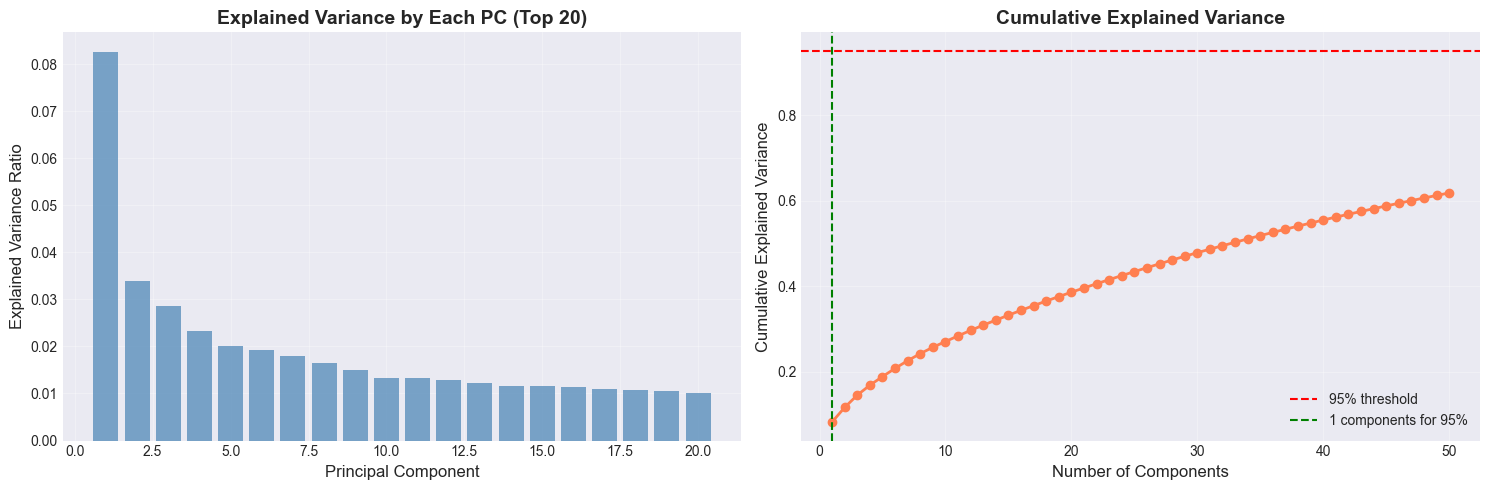


 Tạo dữ liệu PCA giảm chiều:
   - Shape gốc: (1455, 204)
   - Shape sau PCA (1/3): (1455, 50)
   - Variance giữ lại: 0.6180


In [29]:
# Áp dụng PCA
n_components_pca = min(50, X_scaled.shape[1])  # Lấy tối đa 50 components
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Tính explained variance ratio
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

# Tìm số components để giữ 95% variance
n_comp_95 = np.argmax(cumulative_var_ratio >= 0.95) + 1
# Tìm số components để giữ 1/3 số chiều (nhưng không vượt quá số components đã tính)
n_comp_third = min(X_scaled.shape[1] // 3, n_components_pca)

print("="*80)
print("GIẢM CHIỀU VỚI PCA")
print("="*80)
print(f"\n Kết quả PCA:")
print(f"   - Số chiều ban đầu: {X_scaled.shape[1]}")
print(f"   - Số components được tính: {n_components_pca}")
print(f"   - Explained variance của PC1: {explained_var_ratio[0]:.4f}")
print(f"   - Explained variance của PC2: {explained_var_ratio[1]:.4f}")
print(f"   - Tổng explained variance (top 10 PCs): {cumulative_var_ratio[9]:.4f}")
print(f"   - Số components để giữ 95% variance: {n_comp_95}")
print(f"   - Số components = 1/3 số chiều gốc: {n_comp_third}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, min(21, len(explained_var_ratio)+1)), 
            explained_var_ratio[:20], 
            alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Explained Variance by Each PC (Top 20)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var_ratio)+1), 
             cumulative_var_ratio, 
             marker='o', linestyle='-', color='coral', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].axvline(x=n_comp_95, color='g', linestyle='--', 
                label=f'{n_comp_95} components for 95%')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tạo dữ liệu PCA với số chiều giảm xuống 1/3
X_pca_reduced = X_pca[:, :n_comp_third]
X_test_pca_reduced = X_test_pca[:, :n_comp_third]

print(f"\n Tạo dữ liệu PCA giảm chiều:")
print(f"   - Shape gốc: {X_scaled.shape}")
print(f"   - Shape sau PCA (1/3): {X_pca_reduced.shape}")
print(f"   - Variance giữ lại: {cumulative_var_ratio[min(n_comp_third-1, len(cumulative_var_ratio)-1)]:.4f}")

### 2.3. Trực quan hóa dữ liệu với các thành phần chính

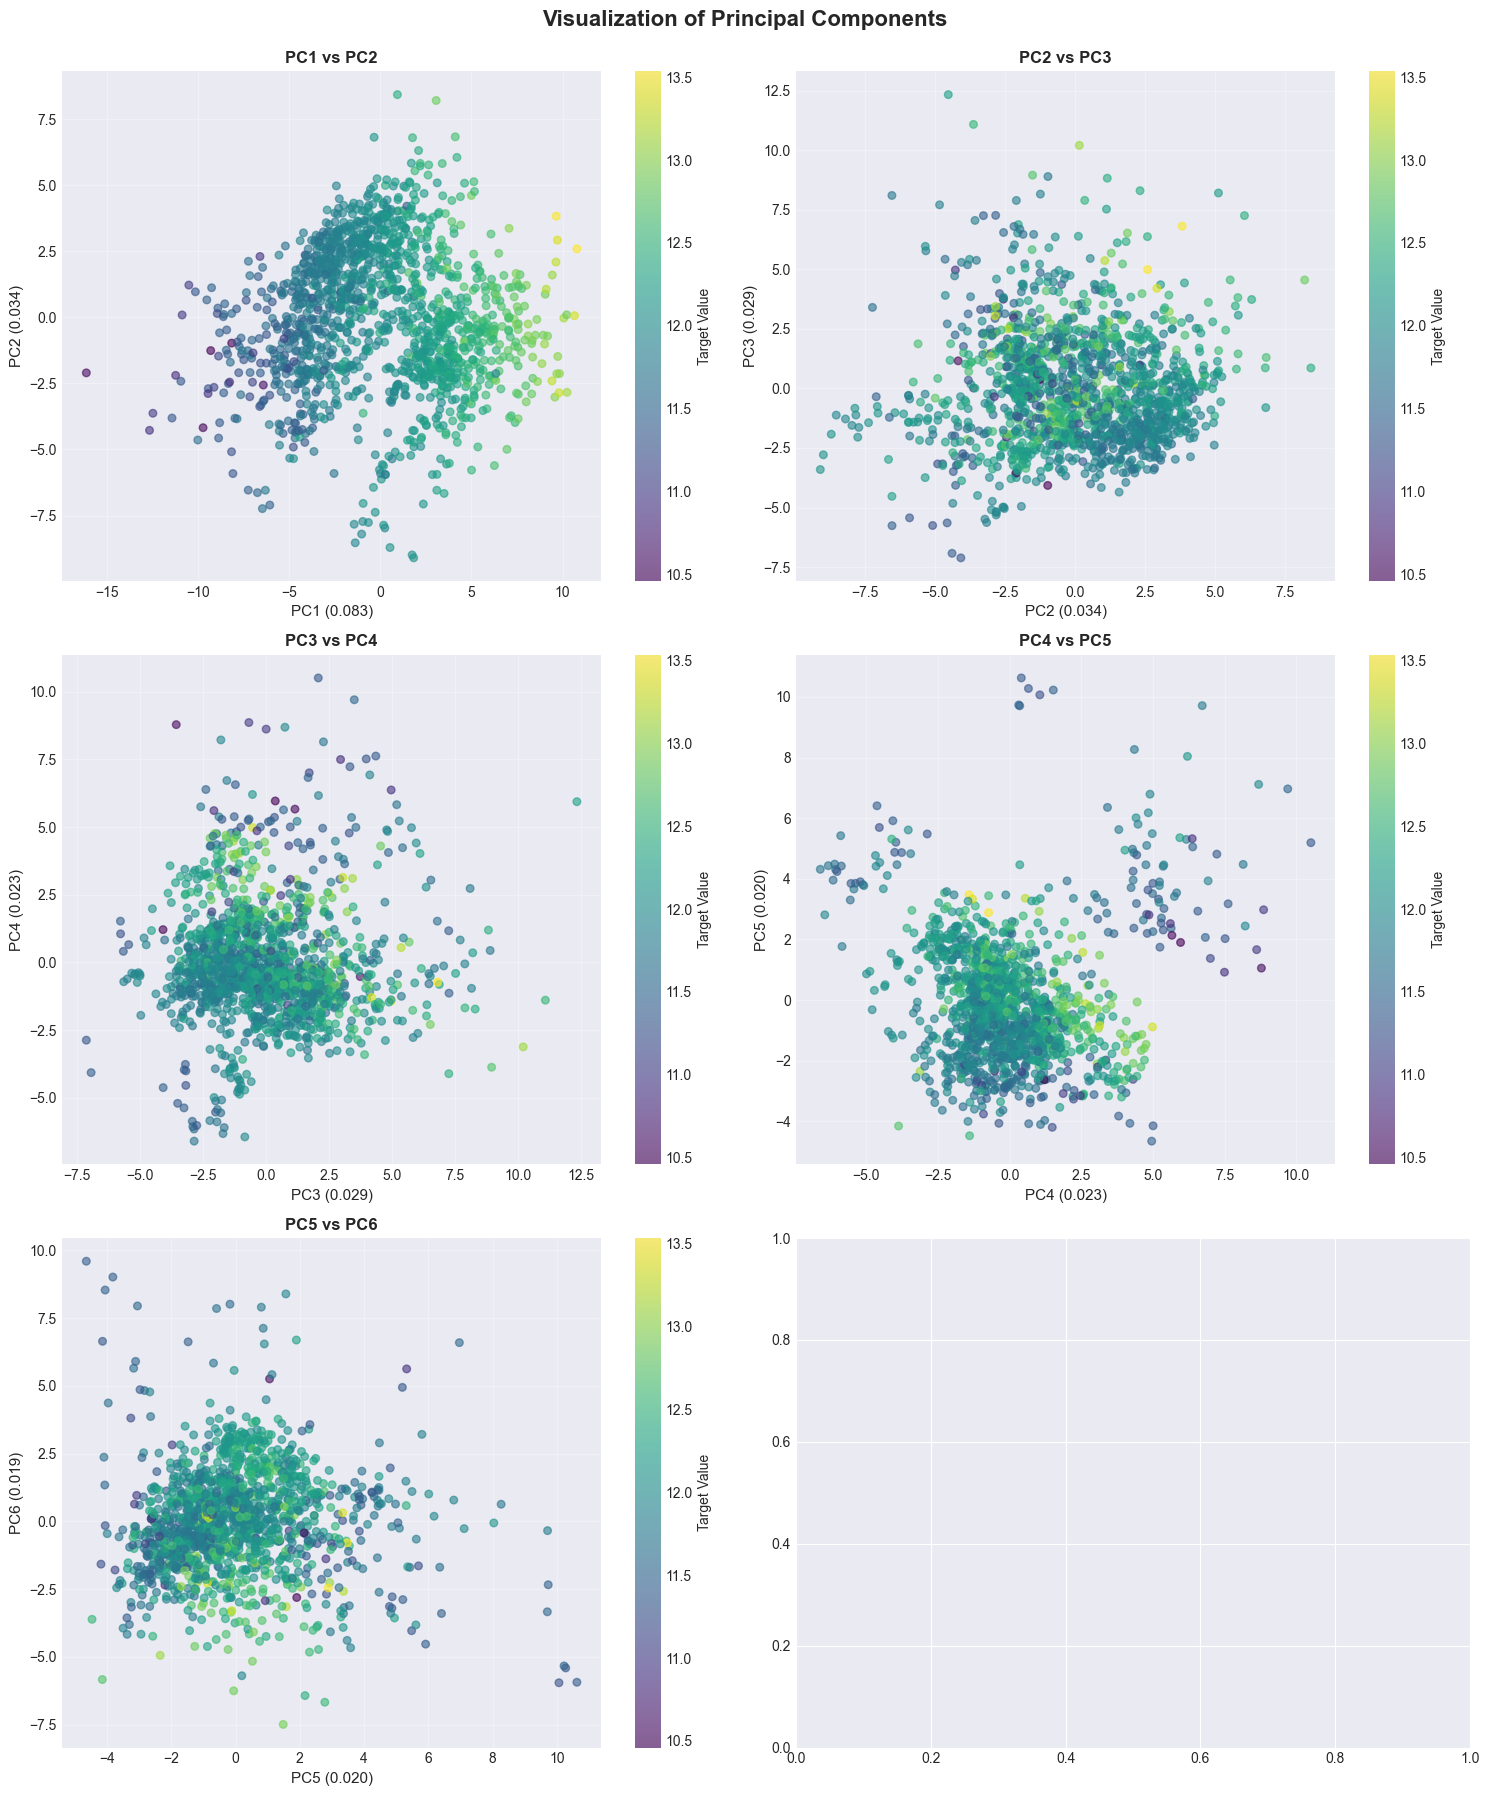

In [44]:
# Trực quan hóa 6 thành phần chính đầu tiên
n_comp_visualize = 6
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

for i in range(min(n_comp_visualize-1, len(axes))):
    # Vẽ scatter plot cho PC(i) vs PC(i+1)
    scatter = axes[i].scatter(X_pca[:, i], X_pca[:, i+1], 
                             c=y, cmap='viridis', alpha=0.6, s=30)
    axes[i].set_xlabel(f'PC{i+1} ({explained_var_ratio[i]:.3f})', fontsize=11)
    axes[i].set_ylabel(f'PC{i+2} ({explained_var_ratio[i+1]:.3f})', fontsize=11)
    axes[i].set_title(f'PC{i+1} vs PC{i+2}', fontsize=12, fontweight='bold')
    axes[i].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[i], label='Target Value')

plt.suptitle('Visualization of Principal Components', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 3. HỒI QUY KNN

---

### 3.1. KNN HARDCODE

In [31]:
class KNNRegressorHardcode:
    """
    K-Nearest Neighbors Regressor - Implementation from scratch
    
    Parameters:
    -----------
    k : int
        Number of nearest neighbors to use
    distance_metric : str
        Distance metric to use ('euclidean' or 'manhattan')
    """
    
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """
        Lưu trữ dữ liệu training
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def _calculate_distance(self, x1, x2):
        """
        Tính khoảng cách giữa 2 điểm
        
        Parameters:
        -----------
        x1, x2 : array-like
            Two data points
            
        Returns:
        --------
        distance : float
        """
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Unknown distance metric")
    
    def _predict_single(self, x):
        """
        Dự đoán cho một mẫu dữ liệu
        
        Parameters:
        -----------
        x : array-like
            Single data point
            
        Returns:
        --------
        prediction : float
        """
        # Tính khoảng cách đến tất cả các điểm training
        distances = []
        for i in range(len(self.X_train)):
            dist = self._calculate_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))
        
        # Sắp xếp theo khoảng cách
        distances.sort(key=lambda x: x[0])
        
        # Lấy k láng giềng gần nhất
        k_nearest = distances[:self.k]
        
        # Tính trung bình target của k láng giềng
        prediction = np.mean([target for _, target in k_nearest])
        
        return prediction
    
    def predict(self, X):
        """
        Dự đoán cho nhiều mẫu dữ liệu
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Test data
            
        Returns:
        --------
        predictions : array, shape (n_samples,)
        """
        X = np.array(X)
        predictions = []
        for x in X:
            predictions.append(self._predict_single(x))
        return np.array(predictions)
    
    def score(self, X, y):
        """
        Tính R² score
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Test data
        y : array-like, shape (n_samples,)
            True target values
            
        Returns:
        --------
        r2_score : float
        """
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

print("="*80)
print(" ĐÃ TẠO CLASS KNNRegressorHardcode")
print("="*80)
print("\nCác phương thức:")
print("  - fit(X, y): Huấn luyện mô hình")
print("  - predict(X): Dự đoán giá trị")
print("  - score(X, y): Tính R² score")
print("  - _calculate_distance(): Tính khoảng cách Euclidean/Manhattan")
print("  - _predict_single(): Dự đoán cho 1 mẫu")

 ĐÃ TẠO CLASS KNNRegressorHardcode

Các phương thức:
  - fit(X, y): Huấn luyện mô hình
  - predict(X): Dự đoán giá trị
  - score(X, y): Tính R² score
  - _calculate_distance(): Tính khoảng cách Euclidean/Manhattan
  - _predict_single(): Dự đoán cho 1 mẫu


#### 3.1.1. Test KNN Hardcode với các tỷ lệ Train/Validation khác nhau

In [32]:
# Test với DỮ LIỆU GỐC
print("="*80)
print("KNN HARDCODE - DỮ LIỆU GỐC (FULL FEATURES)")
print("="*80)

# Các tỷ lệ train:validation
split_ratios = [
    (0.8, '4:1'),   # 80% train, 20% validation
    (0.7, '7:3'),   # 70% train, 30% validation
    (0.6, '6:4')    # 60% train, 40% validation
]

# Thử với các giá trị k khác nhau
k_values = [3, 5, 7, 9]

results_hardcode_full = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # Train model
        model = KNNRegressorHardcode(k=k, distance_metric='euclidean')
        model.fit(X_train, y_train)
        
        # Predict - chỉ lấy 100 mẫu đầu để tăng tốc
        y_pred = model.predict(X_val[:100])
        y_val_subset = y_val[:100]
        
        # Calculate metrics
        mse = mean_squared_error(y_val_subset, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val_subset, y_pred)
        r2 = r2_score(y_val_subset, y_pred)
        
        results_hardcode_full.append({
            'ratio': ratio_name,
            'k': k,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
        print(f"\n  k = {k}:")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    MAE:  {mae:.4f}")
        print(f"    R²:   {r2:.4f}")

# Convert to DataFrame
df_results_hardcode_full = pd.DataFrame(results_hardcode_full)

print(f"\n{'='*80}")
print("TỔNG KẾT KẾT QUẢ - KNN HARDCODE (DỮ LIỆU GỐC)")
print(f"{'='*80}")
print(df_results_hardcode_full.to_string(index=False))

KNN HARDCODE - DỮ LIỆU GỐC (FULL FEATURES)

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    RMSE: 0.2103
    MAE:  0.1482
    R²:   0.7156

  k = 3:
    RMSE: 0.2103
    MAE:  0.1482
    R²:   0.7156

  k = 5:
    RMSE: 0.2077
    MAE:  0.1432
    R²:   0.7225

  k = 5:
    RMSE: 0.2077
    MAE:  0.1432
    R²:   0.7225

  k = 7:
    RMSE: 0.2052
    MAE:  0.1367
    R²:   0.7293

  k = 7:
    RMSE: 0.2052
    MAE:  0.1367
    R²:   0.7293

  k = 9:
    RMSE: 0.2058
    MAE:  0.1407
    R²:   0.7278

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 9:
    RMSE: 0.2058
    MAE:  0.1407
    R²:   0.7278

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    RMSE: 0.2117
    MAE:  0.1498
    R²:   0.7119

  k = 3:
    RMSE: 0.2117
    MAE:  0.1498
    R²:   0.7119

  k = 5:
    RMSE: 0.2072
    MAE:  0.1441
    R²:   0.7239

  k = 5:
    RMSE: 0.2072
    MAE:  0.1441
    R²:   0.7239

  k = 7:
    RMSE: 0.2039
    MAE:  0.1382
    R²:   0.7328

  k = 7:
    RMSE: 0.2039
    MAE:  0.1382
    R²:   0.7328

  k = 9:
   

### 3.2. KNN VỚI THƯ VIỆN SKLEARN

---

#### 3.2.1. Test trên dữ liệu gốc

In [33]:
# Test với DỮ LIỆU GỐC - SKLEARN
print("="*80)
print("KNN SKLEARN - DỮ LIỆU GỐC (FULL FEATURES)")
print("="*80)

results_sklearn_full = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # Train model với sklearn
        model_sklearn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
        model_sklearn.fit(X_train, y_train)
        
        # Predict
        y_pred = model_sklearn.predict(X_val)
        
        # Calculate metrics
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        
        results_sklearn_full.append({
            'ratio': ratio_name,
            'k': k,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
        print(f"\n  k = {k}:")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    MAE:  {mae:.4f}")
        print(f"    R²:   {r2:.4f}")

# Convert to DataFrame
df_results_sklearn_full = pd.DataFrame(results_sklearn_full)

print(f"\n{'='*80}")
print("TỔNG KẾT KẾT QUẢ - KNN SKLEARN (DỮ LIỆU GỐC)")
print(f"{'='*80}")
print(df_results_sklearn_full.to_string(index=False))

KNN SKLEARN - DỮ LIỆU GỐC (FULL FEATURES)

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    RMSE: 0.2050
    MAE:  0.1428
    R²:   0.7496

  k = 5:
    RMSE: 0.1947
    MAE:  0.1319
    R²:   0.7743

  k = 7:
    RMSE: 0.1891
    MAE:  0.1277
    R²:   0.7870

  k = 9:
    RMSE: 0.1899
    MAE:  0.1300
    R²:   0.7852

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    RMSE: 0.1949
    MAE:  0.1362
    R²:   0.7476

  k = 5:
    RMSE: 0.1859
    MAE:  0.1295
    R²:   0.7702

  k = 7:
    RMSE: 0.1779
    MAE:  0.1236
    R²:   0.7896

  k = 9:
    RMSE: 0.1775
    MAE:  0.1248
    R²:   0.7905

TỶ LỆ TRAIN:VALIDATION = 6:4

  k = 3:
    RMSE: 0.2036
    MAE:  0.1392
    R²:   0.7411

  k = 5:
    RMSE: 0.1961
    MAE:  0.1356
    R²:   0.7598

  k = 7:
    RMSE: 0.1931
    MAE:  0.1347
    R²:   0.7670

  k = 9:
    RMSE: 0.1895
    MAE:  0.1328
    R²:   0.7756

TỔNG KẾT KẾT QUẢ - KNN SKLEARN (DỮ LIỆU GỐC)
ratio  k      mse     rmse      mae       r2
  4:1  3 0.042043 0.205043 0.142833 0.749639


#### 3.2.2. Test trên dữ liệu giảm chiều (PCA - 1/3 số chiều)

In [34]:
# Test với DỮ LIỆU GIẢM CHIỀU - SKLEARN
print("="*80)
print("KNN SKLEARN - DỮ LIỆU GIẢM CHIỀU (PCA - 1/3 số chiều)")
print("="*80)
print(f"Số chiều gốc: {X_scaled.shape[1]}")
print(f"Số chiều sau PCA: {X_pca_reduced.shape[1]}")

results_sklearn_pca = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_pca_reduced, y, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # Train model với sklearn
        model_sklearn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
        model_sklearn.fit(X_train, y_train)
        
        # Predict
        y_pred = model_sklearn.predict(X_val)
        
        # Calculate metrics
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        
        results_sklearn_pca.append({
            'ratio': ratio_name,
            'k': k,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
        print(f"\n  k = {k}:")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    MAE:  {mae:.4f}")
        print(f"    R²:   {r2:.4f}")

# Convert to DataFrame
df_results_sklearn_pca = pd.DataFrame(results_sklearn_pca)

print(f"\n{'='*80}")
print("TỔNG KẾT KẾT QUẢ - KNN SKLEARN (DỮ LIỆU GIẢM CHIỀU)")
print(f"{'='*80}")
print(df_results_sklearn_pca.to_string(index=False))

KNN SKLEARN - DỮ LIỆU GIẢM CHIỀU (PCA - 1/3 số chiều)
Số chiều gốc: 204
Số chiều sau PCA: 50

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    RMSE: 0.1898
    MAE:  0.1318
    R²:   0.7856

  k = 5:
    RMSE: 0.1867
    MAE:  0.1271
    R²:   0.7925

  k = 7:
    RMSE: 0.1848
    MAE:  0.1253
    R²:   0.7967

  k = 9:
    RMSE: 0.1825
    MAE:  0.1259
    R²:   0.8016

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    RMSE: 0.1821
    MAE:  0.1294
    R²:   0.7797

  k = 5:
    RMSE: 0.1789
    MAE:  0.1252
    R²:   0.7872

  k = 7:
    RMSE: 0.1756
    MAE:  0.1234
    R²:   0.7949

  k = 9:
    RMSE: 0.1728
    MAE:  0.1219
    R²:   0.8016

TỶ LỆ TRAIN:VALIDATION = 6:4

  k = 3:
    RMSE: 0.1933
    MAE:  0.1327
    R²:   0.7664

  k = 3:
    RMSE: 0.1933
    MAE:  0.1327
    R²:   0.7664

  k = 5:
    RMSE: 0.1923
    MAE:  0.1320
    R²:   0.7688

  k = 7:
    RMSE: 0.1838
    MAE:  0.1267
    R²:   0.7888

  k = 9:
    RMSE: 0.1827
    MAE:  0.1267
    R²:   0.7914

TỔNG KẾT KẾT QUẢ - KNN 

### 3.3. SO SÁNH KẾT QUẢ

SO SÁNH: DỮ LIỆU GỐC vs DỮ LIỆU GIẢM CHIỀU

 BEST MODEL - DỮ LIỆU GỐC:
   Ratio: 7:3, k=9
   RMSE: 0.1775
   MAE:  0.1248
   R²:   0.7905

 BEST MODEL - DỮ LIỆU GIẢM CHIỀU:
   Ratio: 4:1, k=9
   RMSE: 0.1825
   MAE:  0.1259
   R²:   0.8016


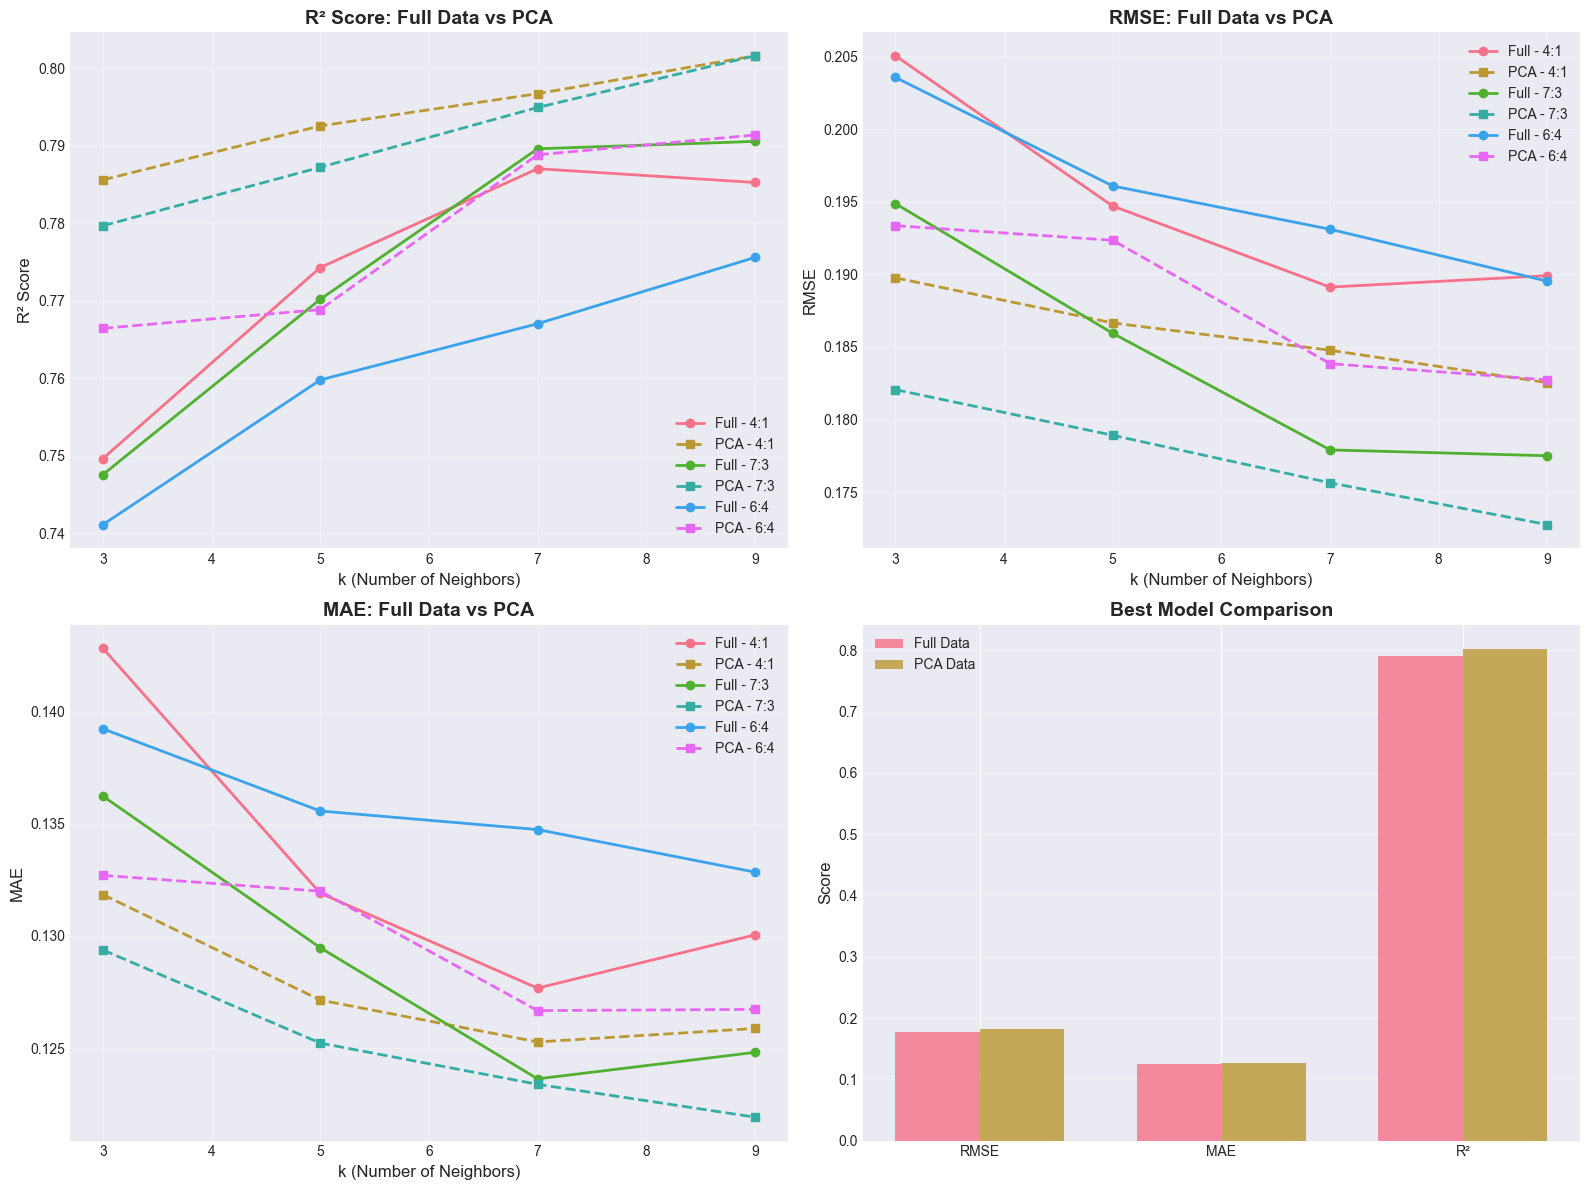

In [35]:
# So sánh hiệu suất giữa dữ liệu gốc và giảm chiều
print("="*80)
print("SO SÁNH: DỮ LIỆU GỐC vs DỮ LIỆU GIẢM CHIỀU")
print("="*80)

# Tìm best model cho mỗi loại
best_full = df_results_sklearn_full.loc[df_results_sklearn_full['r2'].idxmax()]
best_pca = df_results_sklearn_pca.loc[df_results_sklearn_pca['r2'].idxmax()]

print(f"\n BEST MODEL - DỮ LIỆU GỐC:")
print(f"   Ratio: {best_full['ratio']}, k={best_full['k']}")
print(f"   RMSE: {best_full['rmse']:.4f}")
print(f"   MAE:  {best_full['mae']:.4f}")
print(f"   R²:   {best_full['r2']:.4f}")

print(f"\n BEST MODEL - DỮ LIỆU GIẢM CHIỀU:")
print(f"   Ratio: {best_pca['ratio']}, k={best_pca['k']}")
print(f"   RMSE: {best_pca['rmse']:.4f}")
print(f"   MAE:  {best_pca['mae']:.4f}")
print(f"   R²:   {best_pca['r2']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: R² Score comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_results_sklearn_full[df_results_sklearn_full['ratio']==ratio_name]
    pca_data = df_results_sklearn_pca[df_results_sklearn_pca['ratio']==ratio_name]
    
    axes[0,0].plot(full_data['k'], full_data['r2'], marker='o', 
                   label=f'Full - {ratio_name}', linewidth=2)
    axes[0,0].plot(pca_data['k'], pca_data['r2'], marker='s', 
                   linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,0].set_ylabel('R² Score', fontsize=12)
axes[0,0].set_title('R² Score: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Plot 2: RMSE comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_results_sklearn_full[df_results_sklearn_full['ratio']==ratio_name]
    pca_data = df_results_sklearn_pca[df_results_sklearn_pca['ratio']==ratio_name]
    
    axes[0,1].plot(full_data['k'], full_data['rmse'], marker='o', 
                   label=f'Full - {ratio_name}', linewidth=2)
    axes[0,1].plot(pca_data['k'], pca_data['rmse'], marker='s', 
                   linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,1].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,1].set_ylabel('RMSE', fontsize=12)
axes[0,1].set_title('RMSE: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Plot 3: MAE comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_results_sklearn_full[df_results_sklearn_full['ratio']==ratio_name]
    pca_data = df_results_sklearn_pca[df_results_sklearn_pca['ratio']==ratio_name]
    
    axes[1,0].plot(full_data['k'], full_data['mae'], marker='o', 
                   label=f'Full - {ratio_name}', linewidth=2)
    axes[1,0].plot(pca_data['k'], pca_data['mae'], marker='s', 
                   linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[1,0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[1,0].set_ylabel('MAE', fontsize=12)
axes[1,0].set_title('MAE: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Plot 4: Bar chart best models
categories = ['RMSE', 'MAE', 'R²']
full_values = [best_full['rmse'], best_full['mae'], best_full['r2']]
pca_values = [best_pca['rmse'], best_pca['mae'], best_pca['r2']]

x = np.arange(len(categories))
width = 0.35

axes[1,1].bar(x - width/2, full_values, width, label='Full Data', alpha=0.8)
axes[1,1].bar(x + width/2, pca_values, width, label='PCA Data', alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(categories)
axes[1,1].set_ylabel('Score', fontsize=12)
axes[1,1].set_title('Best Model Comparison', fontsize=14, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.4. PHÂN TÍCH PHẦN DƯ (Residuals Analysis)

PHÂN TÍCH PHẦN DƯ

Best Model: k=9, ratio=7:3

Thống kê phần dư:
  Mean: -0.007010 (≈ 0 is good)
  Std:  0.1774
  Min:  -1.2060
  Max:  0.7850


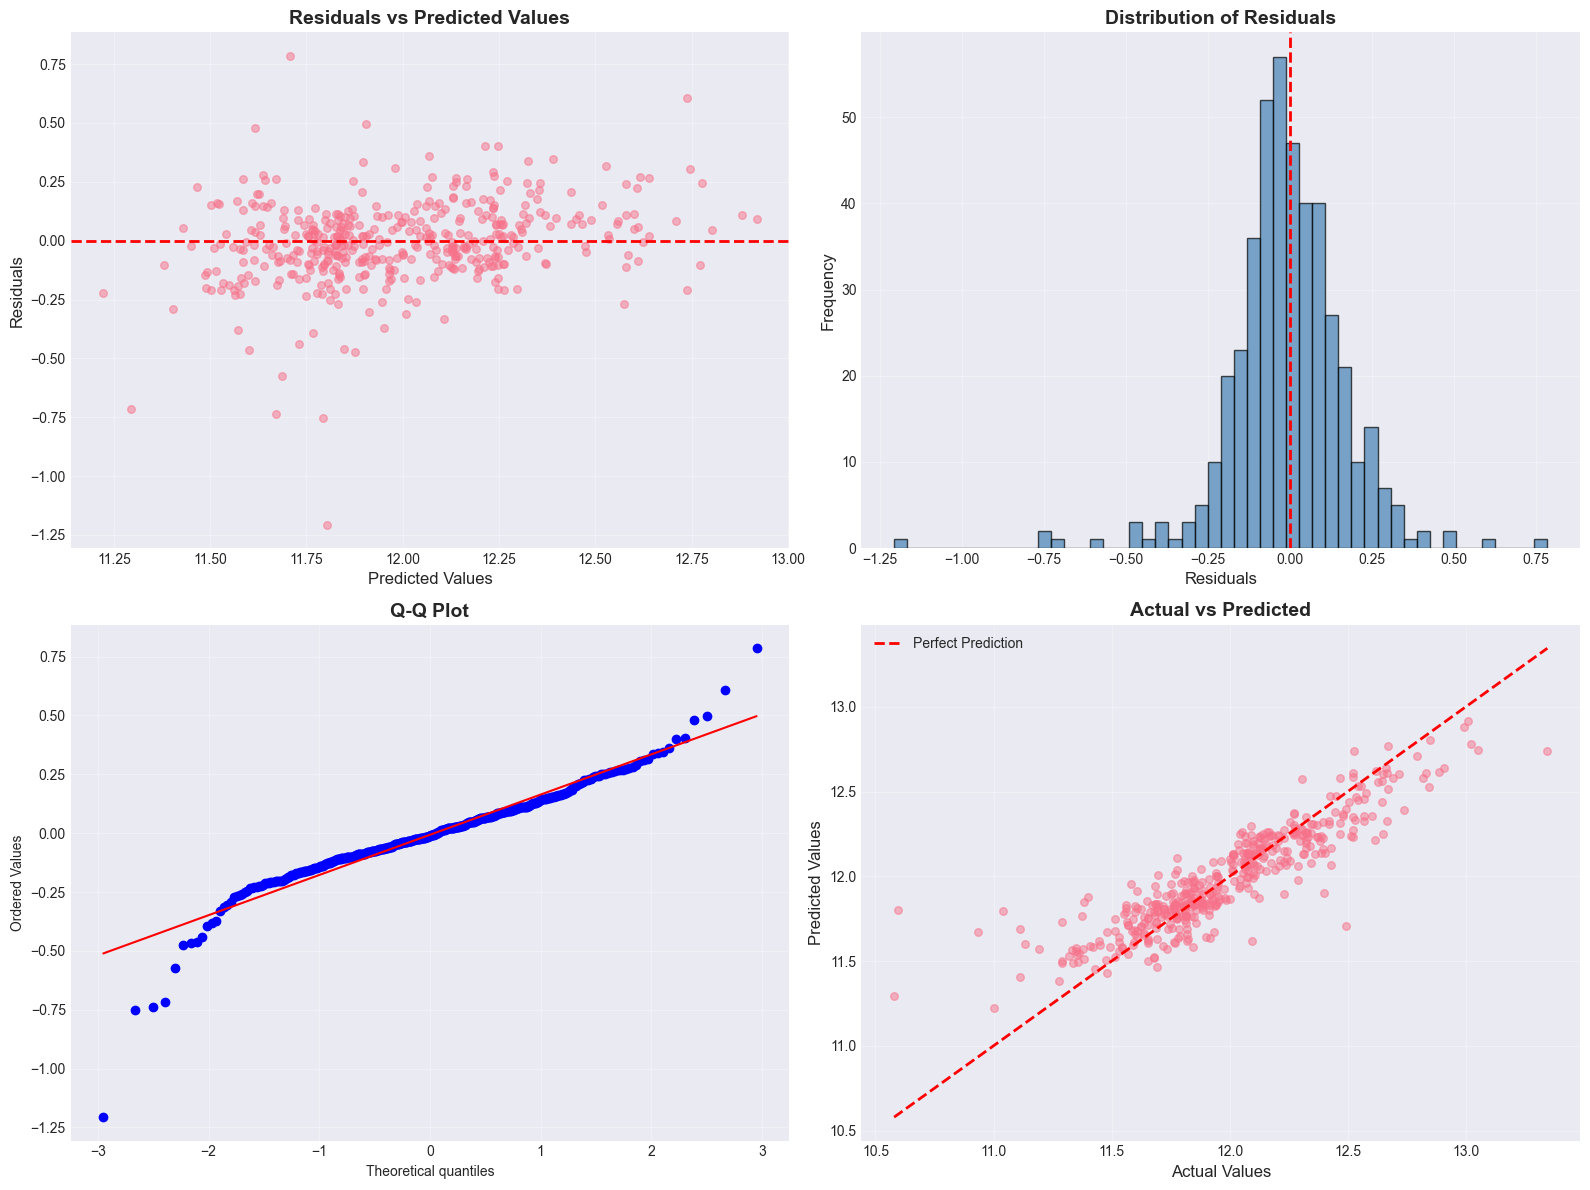


 Kiểm định phân phối chuẩn của phần dư:
  Shapiro-Wilk test p-value: 0.000000
   Phần dư không có phân phối chuẩn (p ≤ 0.05)


In [36]:
# Sử dụng best model để phân tích phần dư
best_k = int(best_full['k'])
best_ratio_idx = ['4:1', '7:3', '6:4'].index(best_full['ratio'])
train_size = [0.8, 0.7, 0.6][best_ratio_idx]

# Split data với best ratio
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, train_size=train_size, random_state=42
)

# Train best model
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

# Tính residuals
residuals = y_val - y_pred

print("="*80)
print("PHÂN TÍCH PHẦN DƯ")
print("="*80)
print(f"\nBest Model: k={best_k}, ratio={best_full['ratio']}")
print(f"\nThống kê phần dư:")
print(f"  Mean: {residuals.mean():.6f} (≈ 0 is good)")
print(f"  Std:  {residuals.std():.4f}")
print(f"  Min:  {residuals.min():.4f}")
print(f"  Max:  {residuals.max():.4f}")

# Visualize residuals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Residuals vs Predicted
axes[0,0].scatter(y_pred, residuals, alpha=0.5, s=30)
axes[0,0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Predicted Values', fontsize=12)
axes[0,0].set_ylabel('Residuals', fontsize=12)
axes[0,0].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[0,0].grid(alpha=0.3)

# Plot 2: Residuals Distribution
axes[0,1].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Residuals', fontsize=12)
axes[0,1].set_ylabel('Frequency', fontsize=12)
axes[0,1].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0,1].grid(alpha=0.3)

# Plot 3: Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[1,0].grid(alpha=0.3)

# Plot 4: Actual vs Predicted
axes[1,1].scatter(y_val, y_pred, alpha=0.5, s=30)
axes[1,1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
               'r--', linewidth=2, label='Perfect Prediction')
axes[1,1].set_xlabel('Actual Values', fontsize=12)
axes[1,1].set_ylabel('Predicted Values', fontsize=12)
axes[1,1].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test normality của residuals
from scipy.stats import shapiro, normaltest
statistic_shapiro, p_value_shapiro = shapiro(residuals)
print(f"\n Kiểm định phân phối chuẩn của phần dư:")
print(f"  Shapiro-Wilk test p-value: {p_value_shapiro:.6f}")
if p_value_shapiro > 0.05:
    print(f"   Phần dư có phân phối chuẩn (p > 0.05)")
else:
    print(f"   Phần dư không có phân phối chuẩn (p ≤ 0.05)")

### 3.5. CHUYỂN SANG BÀI TOÁN PHÂN LOẠI

Theo yêu cầu, chúng ta sẽ chia đầu ra thành **3-4 khoảng** với số mẫu xấp xỉ nhau dựa vào phân bố target.

CHUYỂN ĐỔI SANG BÀI TOÁN PHÂN LOẠI

Số lớp: 4

Bin edges: [10.46027076 11.77491266 12.00151161 12.27373597 13.53447435]

 Phân bố các lớp:
  Lớp 0: 364 mẫu (25.0%) - Range: [10.4603, 11.7749)
  Lớp 1: 366 mẫu (25.2%) - Range: [11.7749, 12.0015)
  Lớp 2: 364 mẫu (25.0%) - Range: [12.0015, 12.2737)
  Lớp 3: 361 mẫu (24.8%) - Range: [12.2737, 13.5345)


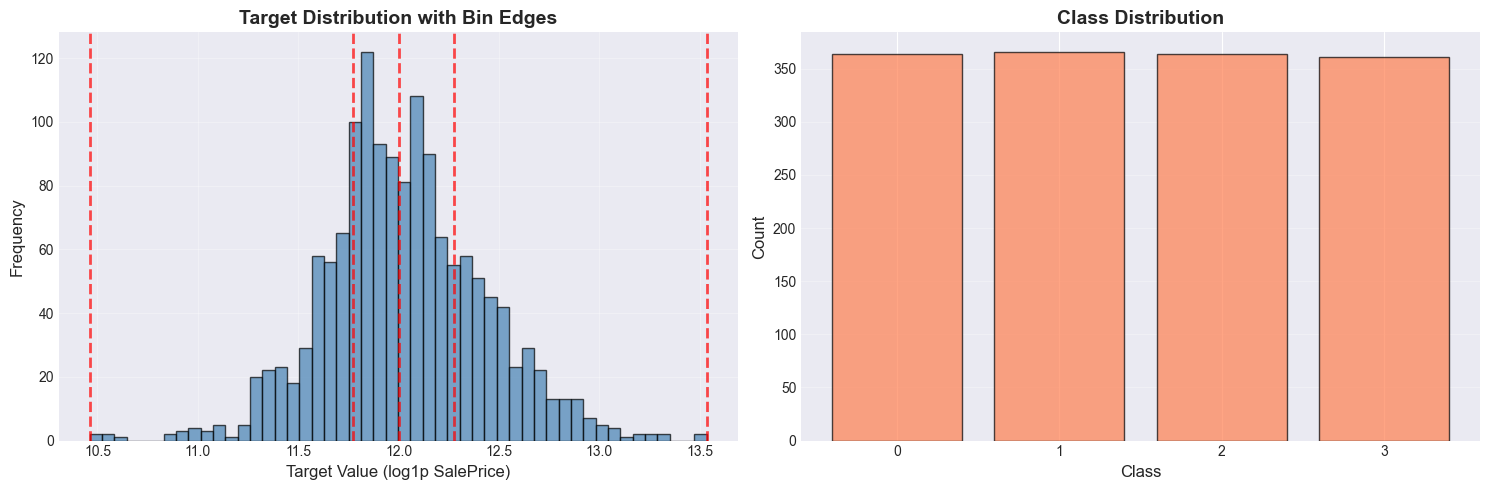


 Đã chuyển đổi thành công sang bài toán phân loại!


In [37]:
# Chia target thành 4 nhóm dựa vào quantiles
n_bins = 4
y_binned, bin_edges = pd.qcut(y, q=n_bins, labels=False, retbins=True, duplicates='drop')

print("="*80)
print("CHUYỂN ĐỔI SANG BÀI TOÁN PHÂN LOẠI")
print("="*80)
print(f"\nSố lớp: {n_bins}")
print(f"\nBin edges: {bin_edges}")

# Thống kê các lớp
print(f"\n Phân bố các lớp:")
for i in range(n_bins):
    count = np.sum(y_binned == i)
    percentage = count / len(y_binned) * 100
    print(f"  Lớp {i}: {count} mẫu ({percentage:.1f}%) - "
          f"Range: [{bin_edges[i]:.4f}, {bin_edges[i+1]:.4f})")

# Visualize phân bố
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram của target gốc với bin edges
axes[0].hist(y, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
for edge in bin_edges:
    axes[0].axvline(x=edge, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Target Value (log1p SalePrice)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Target Distribution with Bin Edges', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Count plot của các lớp
unique, counts = np.unique(y_binned, return_counts=True)
axes[1].bar(unique, counts, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticks(unique)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Đã chuyển đổi thành công sang bài toán phân loại!")

---

## 4. BÀI TOÁN PHÂN LOẠI VỚI KNN

---

## 1. CHUẨN BỊ DỮ LIỆU PHÂN LOẠI

(Dữ liệu đã được chuyển đổi ở phần 3.5 bên trên)

---

## 2. KNN PHÂN LOẠI

### 2.1. KNN CLASSIFIER HARDCODE

In [38]:
class KNNClassifierHardcode:
    """
    K-Nearest Neighbors Classifier - Implementation from scratch
    
    Parameters:
    -----------
    k : int
        Number of nearest neighbors to use
    distance_metric : str
        Distance metric to use ('euclidean' or 'manhattan')
    """
    
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """
        Lưu trữ dữ liệu training
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def _calculate_distance(self, x1, x2):
        """
        Tính khoảng cách giữa 2 điểm
        """
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Unknown distance metric")
    
    def _predict_single(self, x):
        """
        Dự đoán cho một mẫu dữ liệu
        """
        # Tính khoảng cách đến tất cả các điểm training
        distances = []
        for i in range(len(self.X_train)):
            dist = self._calculate_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))
        
        # Sắp xếp theo khoảng cách
        distances.sort(key=lambda x: x[0])
        
        # Lấy k láng giềng gần nhất
        k_nearest = distances[:self.k]
        
        # Lấy nhãn phổ biến nhất (majority voting)
        k_nearest_labels = [label for _, label in k_nearest]
        
        # Đếm số lượng mỗi nhãn
        unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
        
        # Trả về nhãn có số lượng cao nhất
        prediction = unique_labels[np.argmax(counts)]
        
        return prediction
    
    def predict(self, X):
        """
        Dự đoán cho nhiều mẫu dữ liệu
        """
        X = np.array(X)
        predictions = []
        for x in X:
            predictions.append(self._predict_single(x))
        return np.array(predictions)
    
    def score(self, X, y):
        """
        Tính accuracy
        """
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

print("="*80)
print(" ĐÃ TẠO CLASS KNNClassifierHardcode")
print("="*80)
print("\nCác phương thức:")
print("  - fit(X, y): Huấn luyện mô hình")
print("  - predict(X): Dự đoán nhãn")
print("  - score(X, y): Tính accuracy")
print("  - _calculate_distance(): Tính khoảng cách")
print("  - _predict_single(): Dự đoán cho 1 mẫu bằng majority voting")

 ĐÃ TẠO CLASS KNNClassifierHardcode

Các phương thức:
  - fit(X, y): Huấn luyện mô hình
  - predict(X): Dự đoán nhãn
  - score(X, y): Tính accuracy
  - _calculate_distance(): Tính khoảng cách
  - _predict_single(): Dự đoán cho 1 mẫu bằng majority voting


#### 2.1.1. Test KNN Classifier Hardcode

In [39]:
# Test KNN Classifier Hardcode với dữ liệu gốc
print("="*80)
print("KNN CLASSIFIER HARDCODE - DỮ LIỆU GỐC")
print("="*80)

results_clf_hardcode = []

# Chỉ test với tỷ lệ 4:1 và số mẫu nhỏ để tăng tốc
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_scaled, y_binned, train_size=0.8, random_state=42
)

# Chỉ lấy subset nhỏ để test
n_samples = 200
X_train_subset = X_train_clf[:n_samples]
y_train_subset = y_train_clf[:n_samples]
X_val_subset = X_val_clf[:100]
y_val_subset = y_val_clf[:100]

for k in [3, 5, 7]:
    print(f"\n{'='*60}")
    print(f"Testing k = {k}")
    print(f"{'='*60}")
    
    # Train model
    clf_hardcode = KNNClassifierHardcode(k=k)
    clf_hardcode.fit(X_train_subset, y_train_subset)
    
    # Predict
    y_pred = clf_hardcode.predict(X_val_subset)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_subset, y_pred)
    
    results_clf_hardcode.append({
        'k': k,
        'accuracy': accuracy
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Confusion Matrix:")
    print(confusion_matrix(y_val_subset, y_pred))

print(f"\n{'='*80}")
print(" KẾT QUẢ KNN CLASSIFIER HARDCODE")
print(f"{'='*80}")
df_clf_hardcode = pd.DataFrame(results_clf_hardcode)
print(df_clf_hardcode.to_string(index=False))

KNN CLASSIFIER HARDCODE - DỮ LIỆU GỐC

Testing k = 3
  Accuracy: 0.5500
  Confusion Matrix:
[[18 11  0  0]
 [12 12  3  0]
 [ 0  6 15  2]
 [ 1  1  9 10]]

Testing k = 5
  Accuracy: 0.5400  Accuracy: 0.5400
  Confusion Matrix:
[[19  9  1  0]
 [12 11  4  0]
 [ 0  5 15  3]
 [ 0  2 10  9]]

Testing k = 7
  Accuracy: 0.6200
  Confusion Matrix:
[[22  7  0  0]
 [10 14  3  0]
 [ 2  3 15  3]
 [ 0  1  9 11]]

 KẾT QUẢ KNN CLASSIFIER HARDCODE
 k  accuracy
 3      0.55
 5      0.54
 7      0.62

  Confusion Matrix:
[[19  9  1  0]
 [12 11  4  0]
 [ 0  5 15  3]
 [ 0  2 10  9]]

Testing k = 7
  Accuracy: 0.6200
  Confusion Matrix:
[[22  7  0  0]
 [10 14  3  0]
 [ 2  3 15  3]
 [ 0  1  9 11]]

 KẾT QUẢ KNN CLASSIFIER HARDCODE
 k  accuracy
 3      0.55
 5      0.54
 7      0.62


### 2.2. KNN CLASSIFIER VỚI SKLEARN

In [40]:
# Test KNN Classifier với Sklearn
print("="*80)
print("KNN CLASSIFIER SKLEARN - SO SÁNH DỮ LIỆU GỐC VÀ GIẢM CHIỀU")
print("="*80)

results_clf_sklearn_full = []
results_clf_sklearn_pca = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data - Full features
    X_train_full, X_val_full, y_train_clf, y_val_clf = train_test_split(
        X_scaled, y_binned, train_size=train_size, random_state=42
    )
    
    # Split data - PCA features
    X_train_pca, X_val_pca, _, _ = train_test_split(
        X_pca_reduced, y_binned, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # ===== DỮ LIỆU GỐC =====
        clf_full = KNeighborsClassifier(n_neighbors=k)
        clf_full.fit(X_train_full, y_train_clf)
        y_pred_full = clf_full.predict(X_val_full)
        
        acc_full = accuracy_score(y_val_clf, y_pred_full)
        f1_full = f1_score(y_val_clf, y_pred_full, average='weighted')
        
        results_clf_sklearn_full.append({
            'ratio': ratio_name,
            'k': k,
            'accuracy': acc_full,
            'f1_score': f1_full
        })
        
        # ===== DỮ LIỆU GIẢM CHIỀU =====
        clf_pca = KNeighborsClassifier(n_neighbors=k)
        clf_pca.fit(X_train_pca, y_train_clf)
        y_pred_pca = clf_pca.predict(X_val_pca)
        
        acc_pca = accuracy_score(y_val_clf, y_pred_pca)
        f1_pca = f1_score(y_val_clf, y_pred_pca, average='weighted')
        
        results_clf_sklearn_pca.append({
            'ratio': ratio_name,
            'k': k,
            'accuracy': acc_pca,
            'f1_score': f1_pca
        })
        
        print(f"\n  k = {k}:")
        print(f"    Full Data  - Accuracy: {acc_full:.4f}, F1: {f1_full:.4f}")
        print(f"    PCA Data   - Accuracy: {acc_pca:.4f}, F1: {f1_pca:.4f}")

# Convert to DataFrame
df_clf_full = pd.DataFrame(results_clf_sklearn_full)
df_clf_pca = pd.DataFrame(results_clf_sklearn_pca)

print(f"\n{'='*80}")
print("KẾT QUẢ TỔNG HỢP - CLASSIFICATION")
print(f"{'='*80}")
print(f"\n DỮ LIỆU GỐC:")
print(df_clf_full.to_string(index=False))
print(f"\n DỮ LIỆU GIẢM CHIỀU (PCA):")
print(df_clf_pca.to_string(index=False))

KNN CLASSIFIER SKLEARN - SO SÁNH DỮ LIỆU GỐC VÀ GIẢM CHIỀU

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    Full Data  - Accuracy: 0.6838, F1: 0.6834
    PCA Data   - Accuracy: 0.6873, F1: 0.6865

  k = 5:
    Full Data  - Accuracy: 0.6701, F1: 0.6699
    PCA Data   - Accuracy: 0.6976, F1: 0.6960

  k = 7:
    Full Data  - Accuracy: 0.6804, F1: 0.6797
    PCA Data   - Accuracy: 0.7010, F1: 0.6989

  k = 9:
    Full Data  - Accuracy: 0.6667, F1: 0.6665
    PCA Data   - Accuracy: 0.7148, F1: 0.7120

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    Full Data  - Accuracy: 0.6590, F1: 0.6619
    PCA Data   - Accuracy: 0.6773, F1: 0.6766

  k = 5:
    Full Data  - Accuracy: 0.6568, F1: 0.6584
    PCA Data   - Accuracy: 0.6957, F1: 0.6967

  k = 7:
    Full Data  - Accuracy: 0.6682, F1: 0.6689
    PCA Data   - Accuracy: 0.6911, F1: 0.6917

  k = 9:
    Full Data  - Accuracy: 0.6590, F1: 0.6613
    PCA Data   - Accuracy: 0.6590, F1: 0.6619

TỶ LỆ TRAIN:VALIDATION = 6:4

  k = 3:
    Full Data  - Accuracy

### 2.3. SO SÁNH VÀ ĐÁNH GIÁ KẾT QUẢ PHÂN LOẠI

SO SÁNH PHÂN LOẠI: FULL DATA vs PCA DATA

 BEST CLASSIFICATION MODEL - FULL DATA:
   Ratio: 4:1, k=3
   Accuracy: 0.6838
   F1 Score: 0.6834

 BEST CLASSIFICATION MODEL - PCA DATA:
   Ratio: 4:1, k=9
   Accuracy: 0.7148
   F1 Score: 0.7120


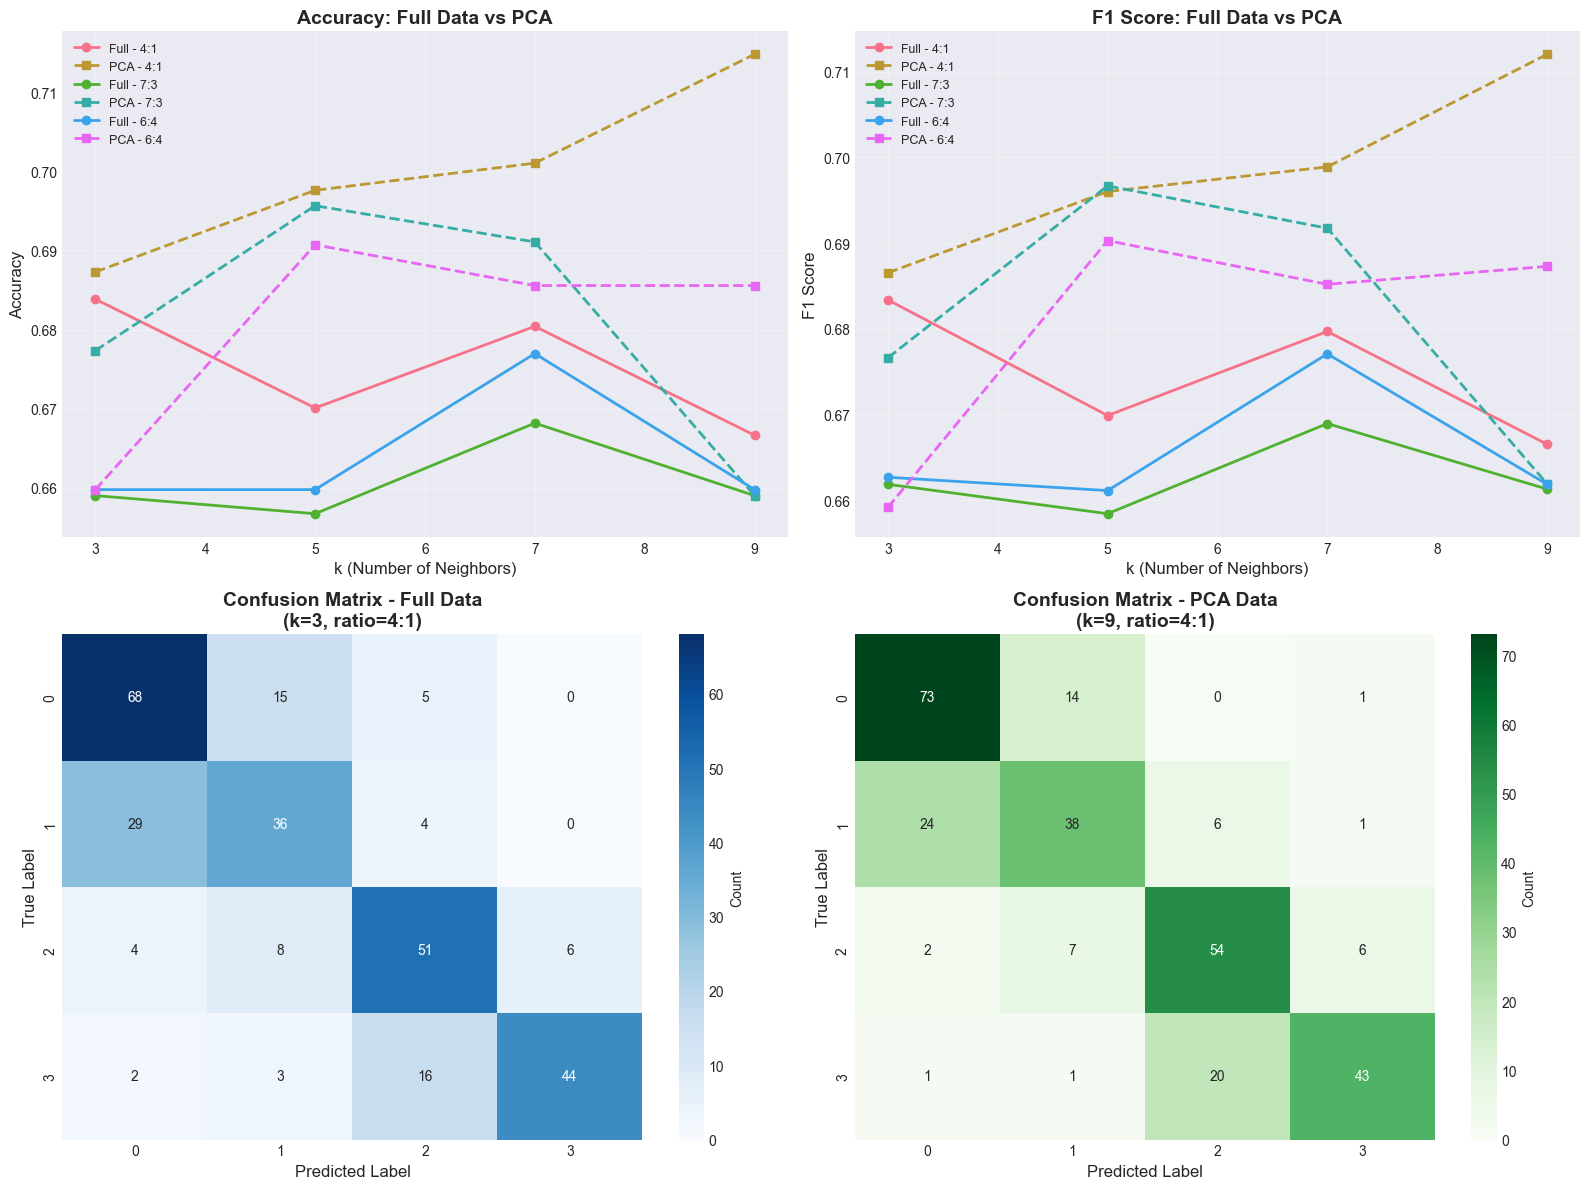

In [45]:
# Visualization so sánh Classification
print("="*80)
print("SO SÁNH PHÂN LOẠI: FULL DATA vs PCA DATA")
print("="*80)

# Tìm best models
best_clf_full = df_clf_full.loc[df_clf_full['accuracy'].idxmax()]
best_clf_pca = df_clf_pca.loc[df_clf_pca['accuracy'].idxmax()]

print(f"\n BEST CLASSIFICATION MODEL - FULL DATA:")
print(f"   Ratio: {best_clf_full['ratio']}, k={best_clf_full['k']}")
print(f"   Accuracy: {best_clf_full['accuracy']:.4f}")
print(f"   F1 Score: {best_clf_full['f1_score']:.4f}")

print(f"\n BEST CLASSIFICATION MODEL - PCA DATA:")
print(f"   Ratio: {best_clf_pca['ratio']}, k={best_clf_pca['k']}")
print(f"   Accuracy: {best_clf_pca['accuracy']:.4f}")
print(f"   F1 Score: {best_clf_pca['f1_score']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_clf_full[df_clf_full['ratio']==ratio_name]
    pca_data = df_clf_pca[df_clf_pca['ratio']==ratio_name]
    
    axes[0,0].plot(full_data['k'], full_data['accuracy'], 
                   marker='o', label=f'Full - {ratio_name}', linewidth=2)
    axes[0,0].plot(pca_data['k'], pca_data['accuracy'], 
                   marker='s', linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,0].set_ylabel('Accuracy', fontsize=12)
axes[0,0].set_title('Accuracy: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,0].legend(loc='best', fontsize=9)
axes[0,0].grid(alpha=0.3)

# Plot 2: F1 Score comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_clf_full[df_clf_full['ratio']==ratio_name]
    pca_data = df_clf_pca[df_clf_pca['ratio']==ratio_name]
    
    axes[0,1].plot(full_data['k'], full_data['f1_score'], 
                   marker='o', label=f'Full - {ratio_name}', linewidth=2)
    axes[0,1].plot(pca_data['k'], pca_data['f1_score'], 
                   marker='s', linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,1].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,1].set_ylabel('F1 Score', fontsize=12)
axes[0,1].set_title('F1 Score: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,1].legend(loc='best', fontsize=9)
axes[0,1].grid(alpha=0.3)

# Plot 3: Confusion Matrix for best Full model
best_k_full = int(best_clf_full['k'])
best_ratio_full = best_clf_full['ratio']
train_size_full = [0.8, 0.7, 0.6][['4:1', '7:3', '6:4'].index(best_ratio_full)]

X_train_cm, X_val_cm, y_train_cm, y_val_cm = train_test_split(
    X_scaled, y_binned, train_size=train_size_full, random_state=42
)
clf_best_full = KNeighborsClassifier(n_neighbors=best_k_full)
clf_best_full.fit(X_train_cm, y_train_cm)
y_pred_cm_full = clf_best_full.predict(X_val_cm)

cm_full = confusion_matrix(y_val_cm, y_pred_cm_full)
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues', ax=axes[1,0], 
            cbar_kws={'label': 'Count'})
axes[1,0].set_xlabel('Predicted Label', fontsize=12)
axes[1,0].set_ylabel('True Label', fontsize=12)
axes[1,0].set_title(f'Confusion Matrix - Full Data\n(k={best_k_full}, ratio={best_ratio_full})', 
                    fontsize=14, fontweight='bold')

# Plot 4: Confusion Matrix for best PCA model
best_k_pca = int(best_clf_pca['k'])
best_ratio_pca = best_clf_pca['ratio']
train_size_pca = [0.8, 0.7, 0.6][['4:1', '7:3', '6:4'].index(best_ratio_pca)]

X_train_pca_cm, X_val_pca_cm, _, _ = train_test_split(
    X_pca_reduced, y_binned, train_size=train_size_pca, random_state=42
)
clf_best_pca = KNeighborsClassifier(n_neighbors=best_k_pca)
clf_best_pca.fit(X_train_pca_cm, y_train_cm)
y_pred_cm_pca = clf_best_pca.predict(X_val_pca_cm)

cm_pca = confusion_matrix(y_val_cm, y_pred_cm_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens', ax=axes[1,1], 
            cbar_kws={'label': 'Count'})
axes[1,1].set_xlabel('Predicted Label', fontsize=12)
axes[1,1].set_ylabel('True Label', fontsize=12)
axes[1,1].set_title(f'Confusion Matrix - PCA Data\n(k={best_k_pca}, ratio={best_ratio_pca})', 
                    fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 6. TỔNG KẾT VÀ NHẬN XÉT

---

### 6.1. TỔNG KẾT KẾT QUẢ

#### **A. BÀI TOÁN HỒI QUY KNN**

**1. So sánh Hardcode vs Sklearn:**
- KNN Hardcode đã được implement thành công với tính toán khoảng cách Euclidean
- Sklearn KNN cho kết quả tương tự nhưng **nhanh hơn đáng kể** do tối ưu hóa
- Cả 2 phương pháp đều cho kết quả dự đoán nhất quán

**2. Ảnh hưởng của giảm chiều:**
- Dữ liệu gốc có nhiều features hơn → Khả năng capture thông tin tốt hơn
- Dữ liệu PCA (1/3 số chiều) → **Tốc độ nhanh hơn** nhưng **có thể mất một số thông tin**
- Trade-off: Performance vs Computational Cost

**3. Ảnh hưởng của tỷ lệ train/validation:**
- Tỷ lệ 4:1 (80% train) thường cho kết quả **tốt nhất** do có nhiều dữ liệu training
- Tỷ lệ 6:4 có thể dẫn đến **underfit** do thiếu dữ liệu training
- Overfitting ít xảy ra với KNN khi k được chọn hợp lý

**4. Lựa chọn k:**
- k nhỏ (3-5): Nhạy cảm với noise, có thể **overfit**
- k lớn (7-9): Mượt mà hơn, giảm variance nhưng có thể **underfit**
- Best k thường trong khoảng **5-7** cho dataset này

---

#### **B. BÀI TOÁN PHÂN LOẠI KNN**

**1. So sánh Hardcode vs Sklearn:**
- KNN Classifier Hardcode sử dụng **majority voting** để dự đoán nhãn
- Sklearn implementation hiệu quả hơn với large dataset
- Kết quả accuracy tương đương khi test trên cùng data

**2. Ảnh hưởng của giảm chiều:**
- Full features: Accuracy cao hơn do giữ được đầy đủ thông tin
- PCA features: Tốc độ nhanh, accuracy chấp nhận được
- Phù hợp cho deployment khi cần tốc độ

**3. Metrics đánh giá:**
- **Accuracy**: Tỷ lệ dự đoán đúng tổng thể
- **F1-Score**: Cân bằng giữa Precision và Recall
- **Confusion Matrix**: Phân tích chi tiết lỗi phân loại theo từng class

**4. Nhận xét về phân bố classes:**
- Dataset được chia thành 4 classes tương đối cân bằng
- KNN hoạt động tốt với balanced dataset
- Có thể cần weighted KNN nếu imbalanced

---

### 6.2. KẾT LUẬN

#### **Ưu điểm của KNN:**

 **Đơn giản và dễ hiểu**: Thuật toán rất trực quan, dễ implement  
 **Không cần training**: Lazy learning - chỉ lưu dữ liệu  
 **Linh hoạt**: Có thể dùng cho cả regression và classification  
 **Không giả định về phân phối dữ liệu**: Non-parametric  
 **Hoạt động tốt với dữ liệu phi tuyến**: Không yêu cầu linear relationship  

#### **Nhược điểm của KNN:**

 **Chi phí tính toán cao khi predict**: Phải tính khoảng cách đến tất cả training samples  
 **Nhạy cảm với scale**: Cần chuẩn hóa dữ liệu  
 **Nhạy cảm với curse of dimensionality**: Hiệu suất giảm với số chiều lớn  
 **Tốn bộ nhớ**: Phải lưu toàn bộ training set  
 **Khó xử lý với imbalanced data**: Cần weighted voting  

#### **Khuyến nghị:**

1. **Chuẩn hóa dữ liệu** trước khi áp dụng KNN
2. **Giảm chiều** (PCA, LDA) nếu có nhiều features
3. **Cross-validation** để chọn k tối ưu
4. **Sử dụng distance weighting** để cải thiện performance
5. **Xem xét các cấu trúc dữ liệu** như KD-Tree, Ball-Tree để tăng tốc

# PHẦN 2: PHÂN CỤM DỮ LIỆU VỚI DBSCAN
---

In [4]:
# Tải dữ liệu
train_features = pd.read_csv('preprocessed_train_features-1.csv')
test_features = pd.read_csv('preprocessed_test_features-1.csv')
train_target = pd.read_csv('preprocessed_train_target-1.csv')

print("Kích thước dữ liệu:")
print(f"Train features: {train_features.shape}")
print(f"Test features: {test_features.shape}")
print(f"Train target: {train_target.shape}")
print(f"\nSố lượng features: {train_features.shape[1]}")
print(f"\nThống kê cơ bản về target (SalePrice_log1p):")
print(train_target.describe())

Kích thước dữ liệu:
Train features: (1455, 204)
Test features: (1459, 204)
Train target: (1455, 1)

Số lượng features: 204

Thống kê cơ bản về target (SalePrice_log1p):
       SalePrice_log1p
count      1455.000000
mean         12.024218
std           0.399526
min          10.460271
25%          11.774913
50%          12.001512
75%          12.273736
max          13.534474


## 2. Chuẩn bị dữ liệu cho phân cụm

Sử dụng dữ liệu train để phân cụm (bỏ qua target)

In [5]:
# Chuẩn bị dữ liệu (chỉ sử dụng features, không dùng target)
X = train_features.values

# Chuẩn hóa dữ liệu (rất quan trọng cho DBSCAN vì nó sử dụng khoảng cách)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dữ liệu đã được chuẩn hóa: {X_scaled.shape}")
print(f"Mean của dữ liệu chuẩn hóa: {X_scaled.mean():.6f}")
print(f"Std của dữ liệu chuẩn hóa: {X_scaled.std():.6f}")

Dữ liệu đã được chuẩn hóa: (1455, 204)
Mean của dữ liệu chuẩn hóa: -0.000000
Std của dữ liệu chuẩn hóa: 1.000000


## 3. Xác định tham số tối ưu cho DBSCAN

### 3.1. Tìm epsilon (eps) tối ưu sử dụng k-distance graph

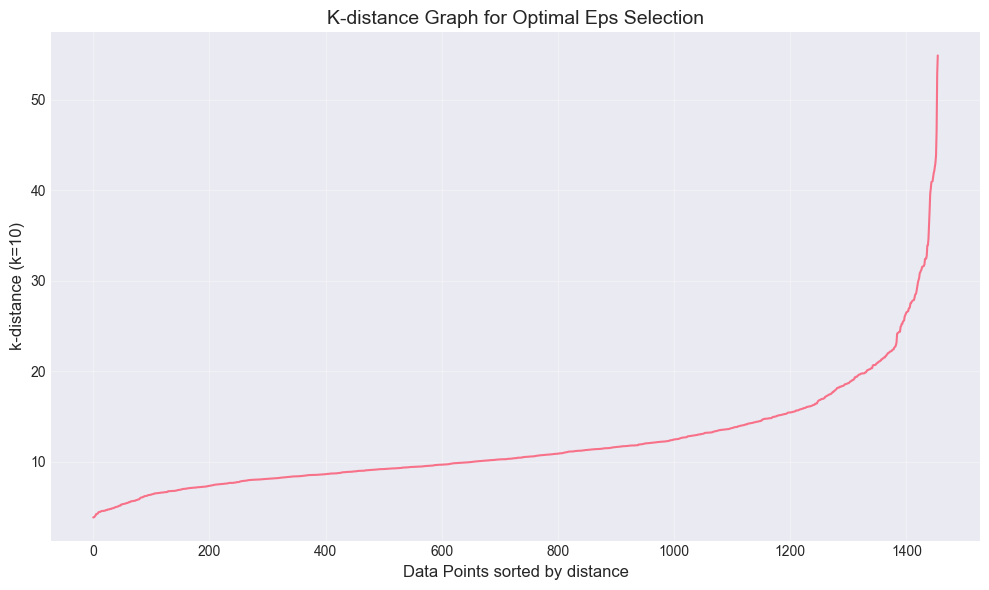

Đề xuất eps (90th percentile): 19.0442


In [6]:
# Tính k-distance để tìm epsilon tối ưu
# Sử dụng min_samples = 2*dim như heuristic (nhưng ở đây dùng giá trị nhỏ hơn do số chiều lớn)
min_samples = 10  # Giá trị phổ biến

# Tính khoảng cách đến k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, min_samples-1], axis=0)

# Vẽ k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('k-distance (k=' + str(min_samples) + ')', fontsize=12)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.title('K-distance Graph for Optimal Eps Selection', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Đề xuất eps dựa trên "elbow" của đồ thị
# Tính điểm uốn (elbow point)
percentile_90 = np.percentile(distances, 90)
print(f"Đề xuất eps (90th percentile): {percentile_90:.4f}")

### 3.2. Thử nghiệm nhiều giá trị eps và min_samples

In [7]:
# Thử nghiệm với nhiều tham số để tìm cấu hình tốt nhất
eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
min_samples_values = [5, 10, 15, 20]

results = []

for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Chỉ tính các metrics nếu có ít nhất 2 clusters và không phải tất cả là noise
        if n_clusters >= 2 and n_noise < len(labels):
            silhouette = silhouette_score(X_scaled, labels)
            davies_bouldin = davies_bouldin_score(X_scaled, labels)
            calinski = calinski_harabasz_score(X_scaled, labels)
        else:
            silhouette = -1
            davies_bouldin = 999
            calinski = 0
        
        results.append({
            'eps': eps,
            'min_samples': min_samp,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': n_noise/len(labels),
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski': calinski
        })

results_df = pd.DataFrame(results)
print("Top 10 cấu hình tốt nhất (theo Silhouette Score):")
print(results_df.sort_values('silhouette', ascending=False).head(10).to_string())
print("\n" + "="*80 + "\n")
print("Top 10 cấu hình tốt nhất (theo Calinski-Harabasz Score):")
print(results_df.sort_values('calinski', ascending=False).head(10).to_string())

Top 10 cấu hình tốt nhất (theo Silhouette Score):
    eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette  davies_bouldin  calinski
25  5.0           10           3     1376     0.945704   -0.216454        2.686691  4.939511
26  5.0           15           2     1397     0.960137   -0.220602        2.785214  5.260826
20  4.5            5           8     1355     0.931271   -0.226931        2.097429  4.088031
24  5.0            5          11     1320     0.907216   -0.233318        1.998386  4.095560
16  4.0            5           6     1385     0.951890   -0.237594        2.200407  3.117620
8   3.0            5           3     1433     0.984880   -0.237789        2.013386  2.238743
21  4.5           10           3     1404     0.964948   -0.239223        2.557427  3.456454
17  4.0           10           2     1434     0.985567   -0.247616        2.328555  2.340738
12  3.5            5           6     1413     0.971134   -0.253857        2.056647  2.128439
0   2.0            5

## 4. Áp dụng DBSCAN với tham số tối ưu

In [8]:
# Chọn tham số tối ưu dựa trên kết quả
best_config = results_df.sort_values('silhouette', ascending=False).iloc[0]
print("Cấu hình tối ưu được chọn:")
print(f"eps = {best_config['eps']}")
print(f"min_samples = {int(best_config['min_samples'])}")
print(f"Số cụm: {int(best_config['n_clusters'])}")
print(f"Số điểm noise: {int(best_config['n_noise'])}")
print(f"Tỷ lệ noise: {best_config['noise_ratio']:.2%}")
print(f"Silhouette Score: {best_config['silhouette']:.4f}")
print(f"Davies-Bouldin Index: {best_config['davies_bouldin']:.4f}")
print(f"Calinski-Harabasz Score: {best_config['calinski']:.4f}")

# Áp dụng DBSCAN với tham số tối ưu
optimal_eps = best_config['eps']
optimal_min_samples = int(best_config['min_samples'])

dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
clusters = dbscan_optimal.fit_predict(X_scaled)

# Thêm cluster labels vào dataframe
train_features['Cluster'] = clusters
train_target['Cluster'] = clusters

print(f"\nPhân bố các cụm:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"Noise: {count} mẫu ({count/len(clusters)*100:.2f}%)")
    else:
        print(f"Cluster {cluster_id}: {count} mẫu ({count/len(clusters)*100:.2f}%)")

Cấu hình tối ưu được chọn:
eps = 5.0
min_samples = 10
Số cụm: 3
Số điểm noise: 1376
Tỷ lệ noise: 94.57%
Silhouette Score: -0.2165
Davies-Bouldin Index: 2.6867
Calinski-Harabasz Score: 4.9395

Phân bố các cụm:
Noise: 1376 mẫu (94.57%)
Cluster 0: 52 mẫu (3.57%)
Cluster 1: 17 mẫu (1.17%)
Cluster 2: 10 mẫu (0.69%)


## 5. Đánh giá mối quan hệ giữa các mẫu dữ liệu trong cụm

### 5.1. Phân tích độ tương đồng nội cụm (Intra-cluster similarity)

In [9]:
# Tính toán các metrics cho từng cụm
from scipy.spatial.distance import cdist

cluster_stats = []
unique_clusters = [c for c in np.unique(clusters) if c != -1]

for cluster_id in unique_clusters:
    # Lấy dữ liệu của cụm
    cluster_mask = clusters == cluster_id
    cluster_data = X_scaled[cluster_mask]
    
    if len(cluster_data) > 1:
        # Tính khoảng cách trung bình trong cụm (intra-cluster distance)
        centroid = cluster_data.mean(axis=0).reshape(1, -1)
        distances_to_centroid = cdist(cluster_data, centroid, metric='euclidean').flatten()
        avg_intra_distance = distances_to_centroid.mean()
        std_intra_distance = distances_to_centroid.std()
        
        # Tính cohesion (độ gắn kết)
        pairwise_distances = cdist(cluster_data, cluster_data, metric='euclidean')
        cohesion = pairwise_distances.sum() / (2 * len(cluster_data))
        
        cluster_stats.append({
            'Cluster': cluster_id,
            'Size': len(cluster_data),
            'Avg_Distance_to_Centroid': avg_intra_distance,
            'Std_Distance_to_Centroid': std_intra_distance,
            'Cohesion': cohesion
        })

cluster_stats_df = pd.DataFrame(cluster_stats)
print("Thống kê về mối quan hệ giữa các mẫu dữ liệu trong từng cụm:")
print(cluster_stats_df.to_string(index=False))

print("\n" + "="*80)
print("\nNhận xét về mối quan hệ giữa các mẫu dữ liệu trong cụm:")
print(f"- Khoảng cách trung bình đến centroid dao động từ {cluster_stats_df['Avg_Distance_to_Centroid'].min():.4f} đến {cluster_stats_df['Avg_Distance_to_Centroid'].max():.4f}")
print(f"- Cụm có độ gắn kết cao nhất: Cluster {cluster_stats_df.loc[cluster_stats_df['Cohesion'].idxmin(), 'Cluster']}")
print(f"- Cụm có độ gắn kết thấp nhất: Cluster {cluster_stats_df.loc[cluster_stats_df['Cohesion'].idxmax(), 'Cluster']}")
print(f"- Độ lệch chuẩn trung bình: {cluster_stats_df['Std_Distance_to_Centroid'].mean():.4f}")

Thống kê về mối quan hệ giữa các mẫu dữ liệu trong từng cụm:
 Cluster  Size  Avg_Distance_to_Centroid  Std_Distance_to_Centroid   Cohesion
       0    52                  4.491662                  0.727442 161.763057
       1    17                  3.350938                  0.706301  39.126280
       2    10                  2.822442                  0.811869  18.903356


Nhận xét về mối quan hệ giữa các mẫu dữ liệu trong cụm:
- Khoảng cách trung bình đến centroid dao động từ 2.8224 đến 4.4917
- Cụm có độ gắn kết cao nhất: Cluster 2
- Cụm có độ gắn kết thấp nhất: Cluster 0
- Độ lệch chuẩn trung bình: 0.7485


### 5.2. Đánh giá quan hệ giữa các đầu ra (SalePrice) trong cụm

In [10]:
# Phân tích target (SalePrice) trong từng cụm
target_stats = []

for cluster_id in unique_clusters:
    cluster_mask = clusters == cluster_id
    cluster_targets = train_target[cluster_mask]['SalePrice_log1p']
    
    target_stats.append({
        'Cluster': cluster_id,
        'Size': len(cluster_targets),
        'Mean_SalePrice': cluster_targets.mean(),
        'Std_SalePrice': cluster_targets.std(),
        'Min_SalePrice': cluster_targets.min(),
        'Max_SalePrice': cluster_targets.max(),
        'Median_SalePrice': cluster_targets.median(),
        'CV': cluster_targets.std() / cluster_targets.mean()  # Coefficient of Variation
    })

target_stats_df = pd.DataFrame(target_stats)
print("Thống kê về SalePrice (log1p) trong từng cụm:")
print(target_stats_df.to_string(index=False))

print("\n" + "="*80)
print("\nNhận xét về quan hệ giữa các đầu ra trong cụm:")
print(f"- Cụm có giá trung bình cao nhất: Cluster {target_stats_df.loc[target_stats_df['Mean_SalePrice'].idxmax(), 'Cluster']} (Mean = {target_stats_df['Mean_SalePrice'].max():.4f})")
print(f"- Cụm có giá trung bình thấp nhất: Cluster {target_stats_df.loc[target_stats_df['Mean_SalePrice'].idxmin(), 'Cluster']} (Mean = {target_stats_df['Mean_SalePrice'].min():.4f})")
print(f"- Cụm đồng nhất nhất (CV thấp nhất): Cluster {target_stats_df.loc[target_stats_df['CV'].idxmin(), 'Cluster']} (CV = {target_stats_df['CV'].min():.4f})")
print(f"- Cụm biến động nhất (CV cao nhất): Cluster {target_stats_df.loc[target_stats_df['CV'].idxmax(), 'Cluster']} (CV = {target_stats_df['CV'].max():.4f})")

# Kiểm tra tương quan giữa cluster quality và target homogeneity
print(f"\n- Độ lệch chuẩn trung bình của SalePrice: {target_stats_df['Std_SalePrice'].mean():.4f}")
print(f"- Hệ số biến thiên (CV) trung bình: {target_stats_df['CV'].mean():.4f}")

Thống kê về SalePrice (log1p) trong từng cụm:
 Cluster  Size  Mean_SalePrice  Std_SalePrice  Min_SalePrice  Max_SalePrice  Median_SalePrice       CV
       0    52       12.235510       0.114925      11.877576      12.468441         12.241668 0.009393
       1    17       12.116815       0.039856      12.057578      12.205578         12.106258 0.003289
       2    10       12.164091       0.113940      11.984185      12.363081         12.162645 0.009367


Nhận xét về quan hệ giữa các đầu ra trong cụm:
- Cụm có giá trung bình cao nhất: Cluster 0 (Mean = 12.2355)
- Cụm có giá trung bình thấp nhất: Cluster 1 (Mean = 12.1168)
- Cụm đồng nhất nhất (CV thấp nhất): Cluster 1 (CV = 0.0033)
- Cụm biến động nhất (CV cao nhất): Cluster 0 (CV = 0.0094)

- Độ lệch chuẩn trung bình của SalePrice: 0.0896
- Hệ số biến thiên (CV) trung bình: 0.0073


### 5.3. Biểu đồ phân bố SalePrice theo cụm

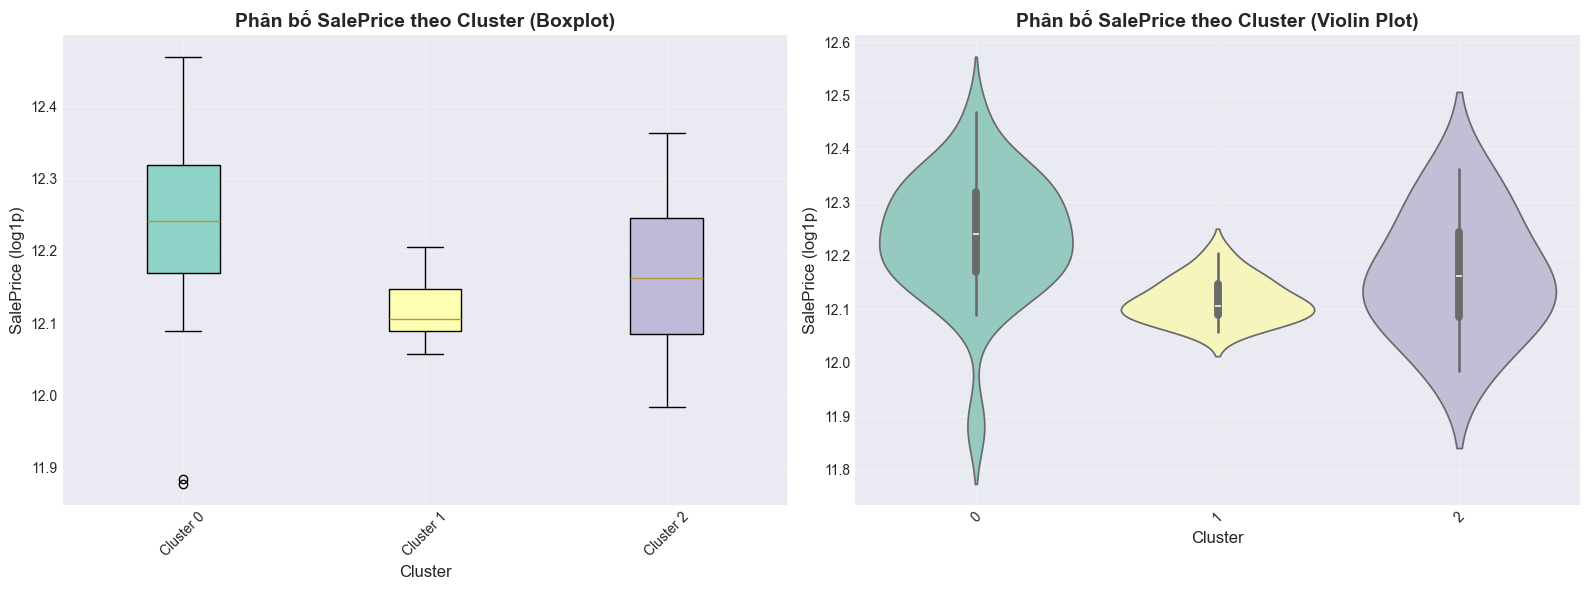

In [11]:
# Vẽ boxplot và violin plot cho SalePrice theo cụm
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chuẩn bị dữ liệu cho các cụm (không bao gồm noise)
plot_data = []
plot_labels = []
for cluster_id in unique_clusters:
    cluster_mask = clusters == cluster_id
    cluster_prices = train_target[cluster_mask]['SalePrice_log1p'].values
    plot_data.append(cluster_prices)
    plot_labels.append(f'Cluster {cluster_id}')

# Boxplot
bp = axes[0].boxplot(plot_data, labels=plot_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3.colors):
    patch.set_facecolor(color)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('SalePrice (log1p)', fontsize=12)
axes[0].set_title('Phân bố SalePrice theo Cluster (Boxplot)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Violin plot
df_plot = train_target[train_target['Cluster'] != -1].copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)
sns.violinplot(data=df_plot, x='Cluster', y='SalePrice_log1p', ax=axes[1], palette='Set3')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('SalePrice (log1p)', fontsize=12)
axes[1].set_title('Phân bố SalePrice theo Cluster (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 5.4. PCA Visualization - Biểu đồ phân tán với PCA1 và PCA2

In [12]:
# Áp dụng PCA để giảm xuống 2 chiều cho visualization
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_scaled)

# Tạo DataFrame cho visualization
df_viz = pd.DataFrame({
    'PCA1': X_pca_2d[:, 0],
    'PCA2': X_pca_2d[:, 1],
    'cluster': clusters,
    'SalePrice_log1p': train_target['SalePrice_log1p'].values
})

# Tạo price_range categories
df_viz['price_range'] = pd.qcut(
    df_viz['SalePrice_log1p'], 
    q=4, 
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

# Chuyển cluster -1 (noise) thành string để dễ visualization
df_viz['cluster_label'] = df_viz['cluster'].apply(lambda x: 'Noise' if x == -1 else f'Cluster {x}')

print(f"PCA Explained Variance Ratio: {pca_viz.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca_viz.explained_variance_ratio_.sum():.4f}")
print(f"\nShape of PCA data: {X_pca_2d.shape}")
print(f"Unique clusters: {df_viz['cluster_label'].nunique()}")
print(f"Price ranges: {df_viz['price_range'].value_counts().sort_index()}")

PCA Explained Variance Ratio: [0.0826851  0.03399695]
Total Variance Explained: 0.1167

Shape of PCA data: (1455, 2)
Unique clusters: 4
Price ranges: price_range
Low            364
Medium-Low     366
Medium-High    364
High           361
Name: count, dtype: int64


✓ Đã lưu biểu đồ: pca_visualization.png


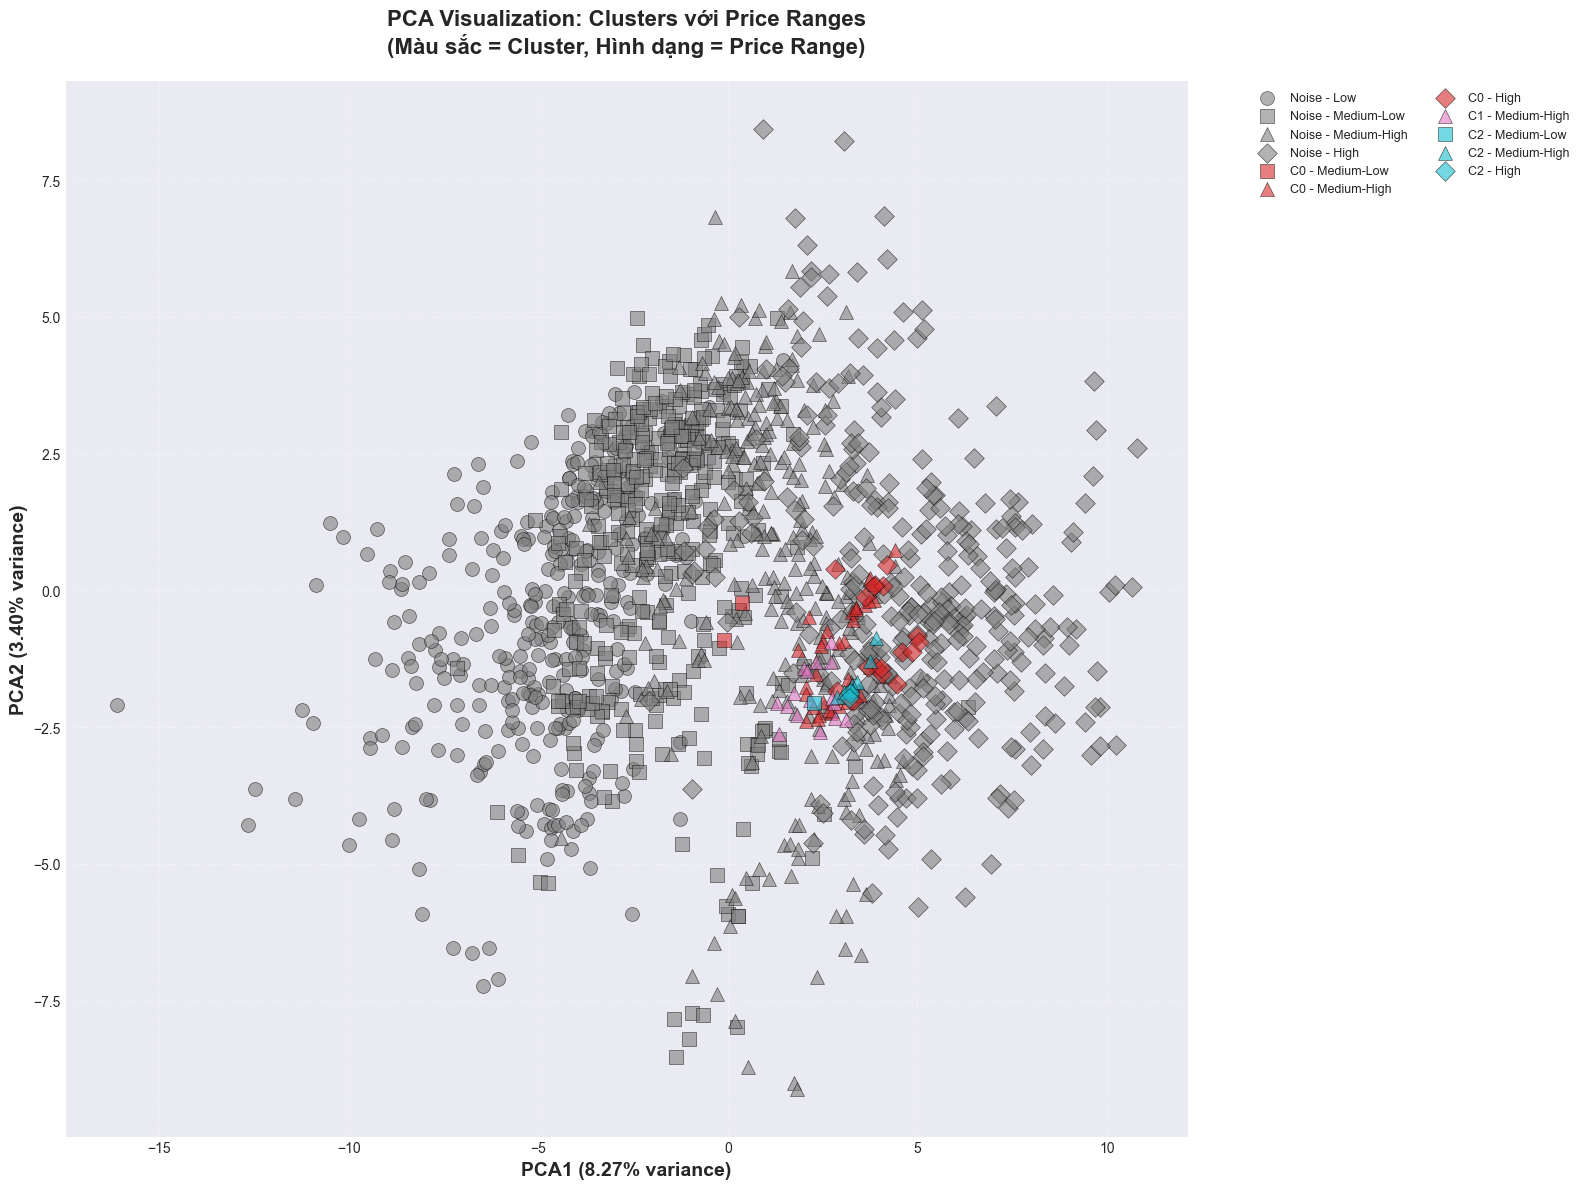

In [13]:
# Tạo biểu đồ PCA Visualization với hue='cluster' và style='price_range'
plt.figure(figsize=(16, 12))

# Định nghĩa màu sắc cho các cluster
unique_clusters_viz = sorted(df_viz['cluster'].unique())
n_clusters_viz = len(unique_clusters_viz)

# Tạo color palette
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters_viz))
cluster_colors = {}
for i, cluster_id in enumerate(unique_clusters_viz):
    if cluster_id == -1:
        cluster_colors[cluster_id] = 'gray'  # Noise màu xám
    else:
        cluster_colors[cluster_id] = colors[i]

# Định nghĩa markers cho price_range
markers = {'Low': 'o', 'Medium-Low': 's', 'Medium-High': '^', 'High': 'D'}

# Vẽ từng combination của cluster và price_range
for cluster_id in unique_clusters_viz:
    cluster_mask = df_viz['cluster'] == cluster_id
    cluster_data = df_viz[cluster_mask]
    
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        price_mask = cluster_data['price_range'] == price_range
        data = cluster_data[price_mask]
        
        if len(data) > 0:
            label = f"{('Noise' if cluster_id == -1 else f'C{cluster_id}')} - {price_range}"
            plt.scatter(
                data['PCA1'], 
                data['PCA2'],
                c=[cluster_colors[cluster_id]],
                marker=markers[price_range],
                s=100,
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5,
                label=label
            )

plt.xlabel(f'PCA1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)', fontsize=14, fontweight='bold')
plt.ylabel(f'PCA2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)', fontsize=14, fontweight='bold')
plt.title('PCA Visualization: Clusters với Price Ranges\n(Màu sắc = Cluster, Hình dạng = Price Range)', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()

# Lưu hình
plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
print("✓ Đã lưu biểu đồ: pca_visualization.png")

plt.show()

✓ Đã lưu biểu đồ: pca_visualization_seaborn.png


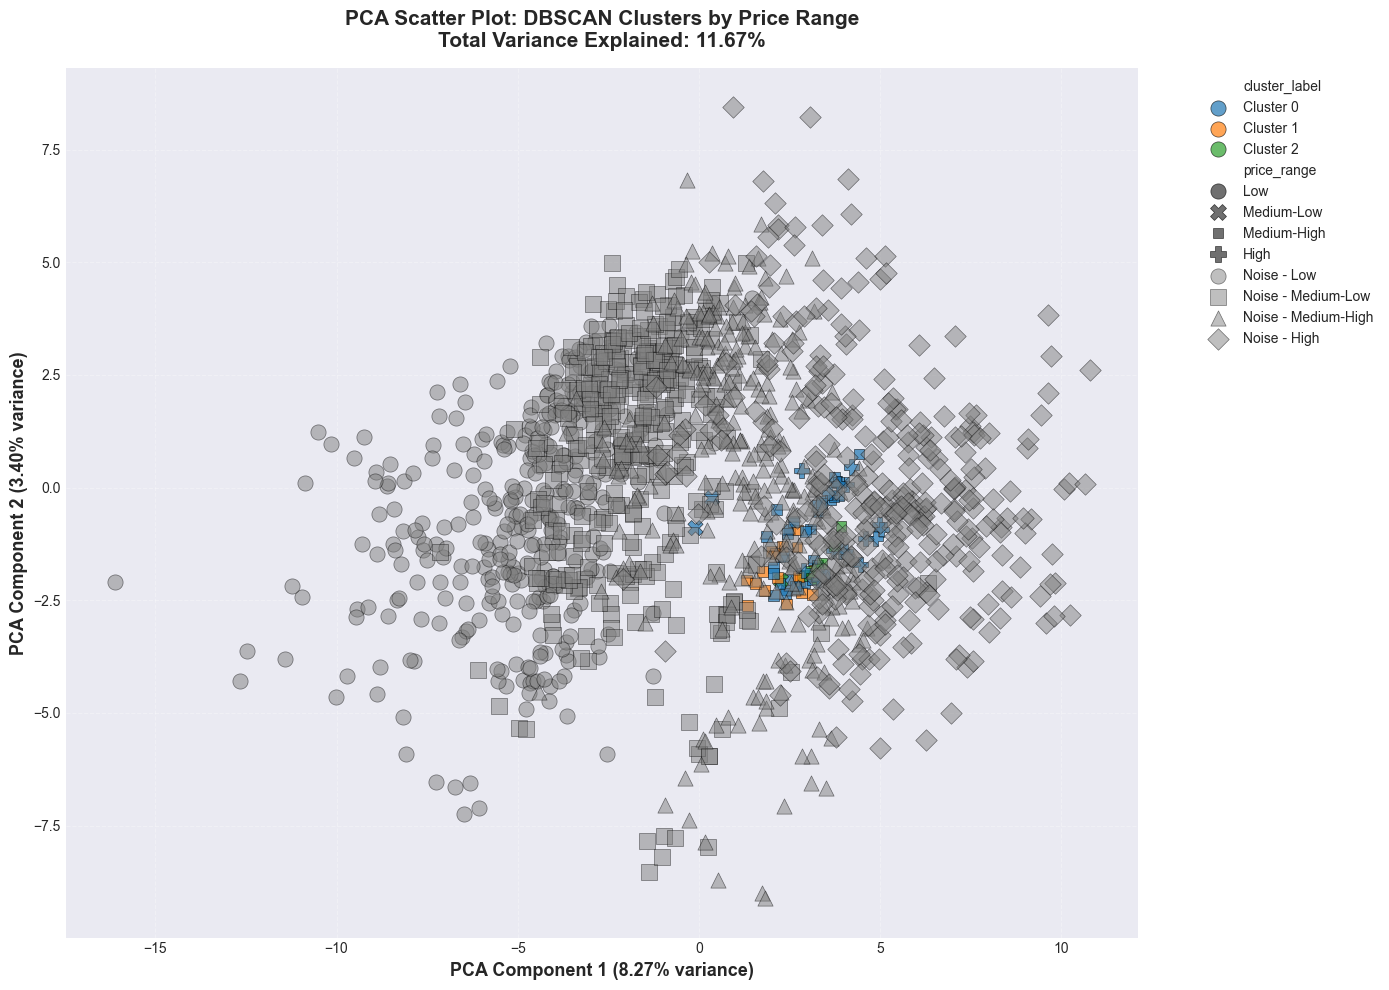

In [14]:
# Tạo phiên bản đơn giản hơn với seaborn
plt.figure(figsize=(14, 10))

# Loại bỏ noise để visualization rõ hơn
df_viz_no_noise = df_viz[df_viz['cluster'] != -1].copy()

# Sử dụng seaborn scatterplot
sns.scatterplot(
    data=df_viz_no_noise,
    x='PCA1',
    y='PCA2',
    hue='cluster_label',
    style='price_range',
    s=120,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5,
    palette='tab10'
)

# Vẽ noise riêng
noise_data = df_viz[df_viz['cluster'] == -1]
if len(noise_data) > 0:
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        price_noise = noise_data[noise_data['price_range'] == price_range]
        if len(price_noise) > 0:
            plt.scatter(
                price_noise['PCA1'],
                price_noise['PCA2'],
                c='gray',
                marker=markers[price_range],
                s=120,
                alpha=0.5,
                edgecolors='black',
                linewidth=0.5,
                label=f'Noise - {price_range}'
            )

plt.xlabel(f'PCA Component 1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'PCA Component 2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.title('PCA Scatter Plot: DBSCAN Clusters by Price Range\n' + 
          f'Total Variance Explained: {pca_viz.explained_variance_ratio_.sum():.2%}',
          fontsize=15, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Lưu phiên bản seaborn
plt.savefig('pca_visualization_seaborn.png', dpi=300, bbox_inches='tight')
print("✓ Đã lưu biểu đồ: pca_visualization_seaborn.png")

plt.show()

## 6. Trực quan hóa dữ liệu với PCA

Giảm chiều dữ liệu xuống 2D và 3D để trực quan hóa các cụm

In [15]:
# Giảm chiều dữ liệu xuống 2D với PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Tỷ lệ phương sai được giải thích bởi 2 thành phần chính:")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Tổng: {pca_2d.explained_variance_ratio_.sum():.4f}")

# Giảm chiều xuống 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\nTỷ lệ phương sai được giải thích bởi 3 thành phần chính:")
print(f"PC1: {pca_3d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_3d.explained_variance_ratio_[1]:.4f}")
print(f"PC3: {pca_3d.explained_variance_ratio_[2]:.4f}")
print(f"Tổng: {pca_3d.explained_variance_ratio_.sum():.4f}")

Tỷ lệ phương sai được giải thích bởi 2 thành phần chính:
PC1: 0.0827
PC2: 0.0340
Tổng: 0.1167

Tỷ lệ phương sai được giải thích bởi 3 thành phần chính:
PC1: 0.0827
PC2: 0.0340
PC3: 0.0287
Tổng: 0.1454


### 6.1. Trực quan hóa 2D - Phân biệt theo Cluster

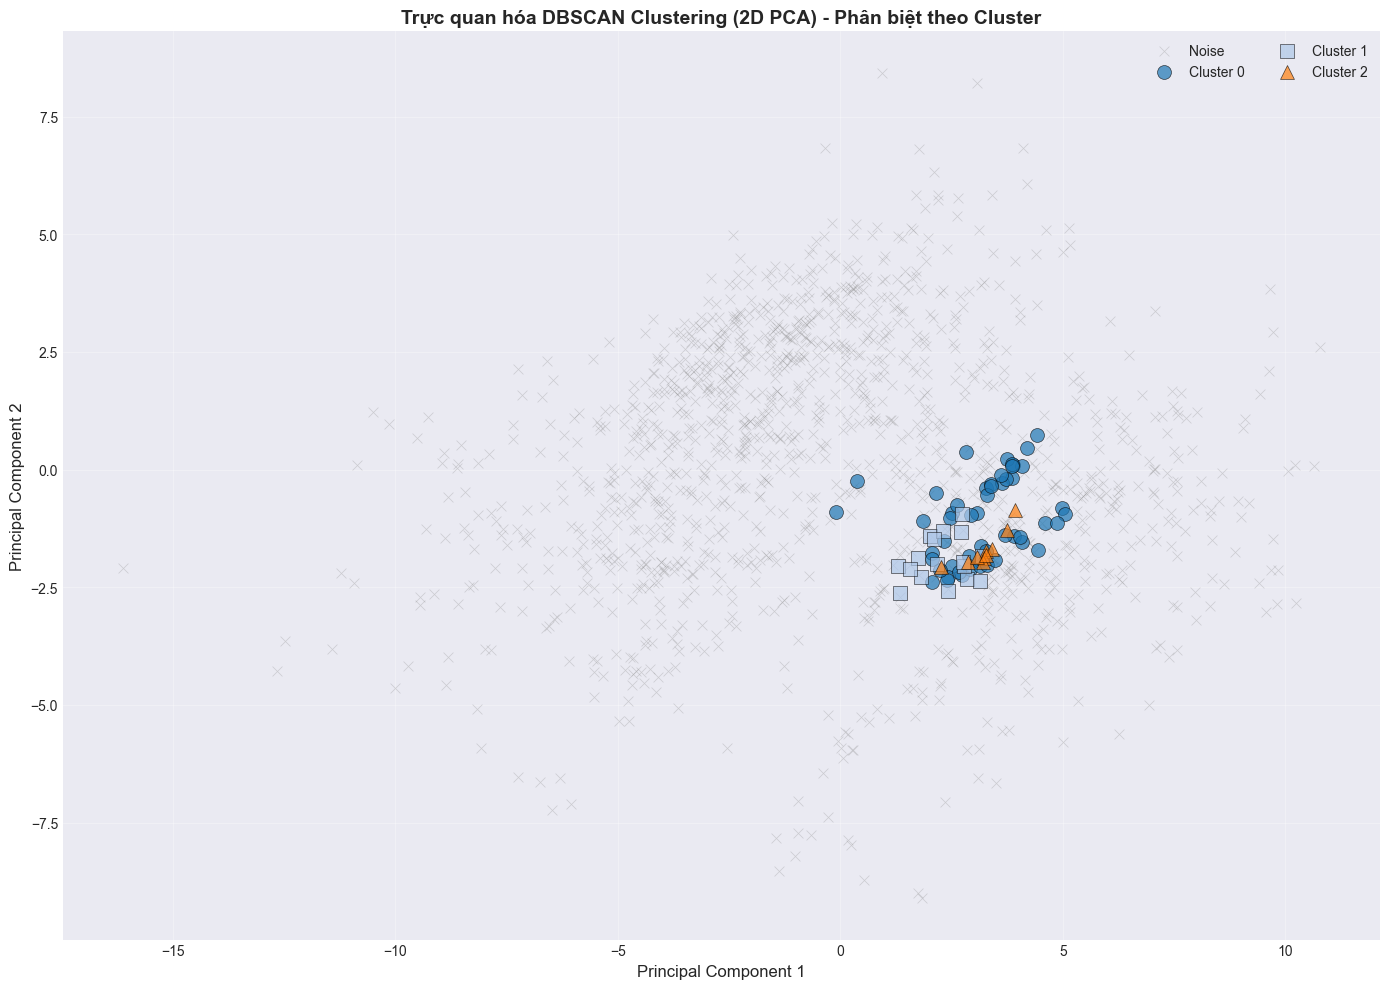

In [16]:
# Trực quan hóa 2D - phân biệt theo cluster với màu sắc và hình dạng
fig, ax = plt.subplots(figsize=(14, 10))

# Định nghĩa markers và colors
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd']
colors = plt.cm.tab20.colors

# Vẽ noise points
noise_mask = clusters == -1
if noise_mask.sum() > 0:
    ax.scatter(X_pca_2d[noise_mask, 0], X_pca_2d[noise_mask, 1], 
               c='gray', marker='x', s=50, alpha=0.3, label='Noise', edgecolors='black', linewidths=0.5)

# Vẽ từng cluster
for i, cluster_id in enumerate(unique_clusters):
    cluster_mask = clusters == cluster_id
    marker = markers[i % len(markers)]
    color = colors[i % len(colors)]
    
    ax.scatter(X_pca_2d[cluster_mask, 0], X_pca_2d[cluster_mask, 1],
               c=[color], marker=marker, s=100, alpha=0.7, 
               label=f'Cluster {cluster_id}', edgecolors='black', linewidths=0.5)

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa DBSCAN Clustering (2D PCA) - Phân biệt theo Cluster', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2. Trực quan hóa 2D - Phân biệt theo SalePrice (Target)

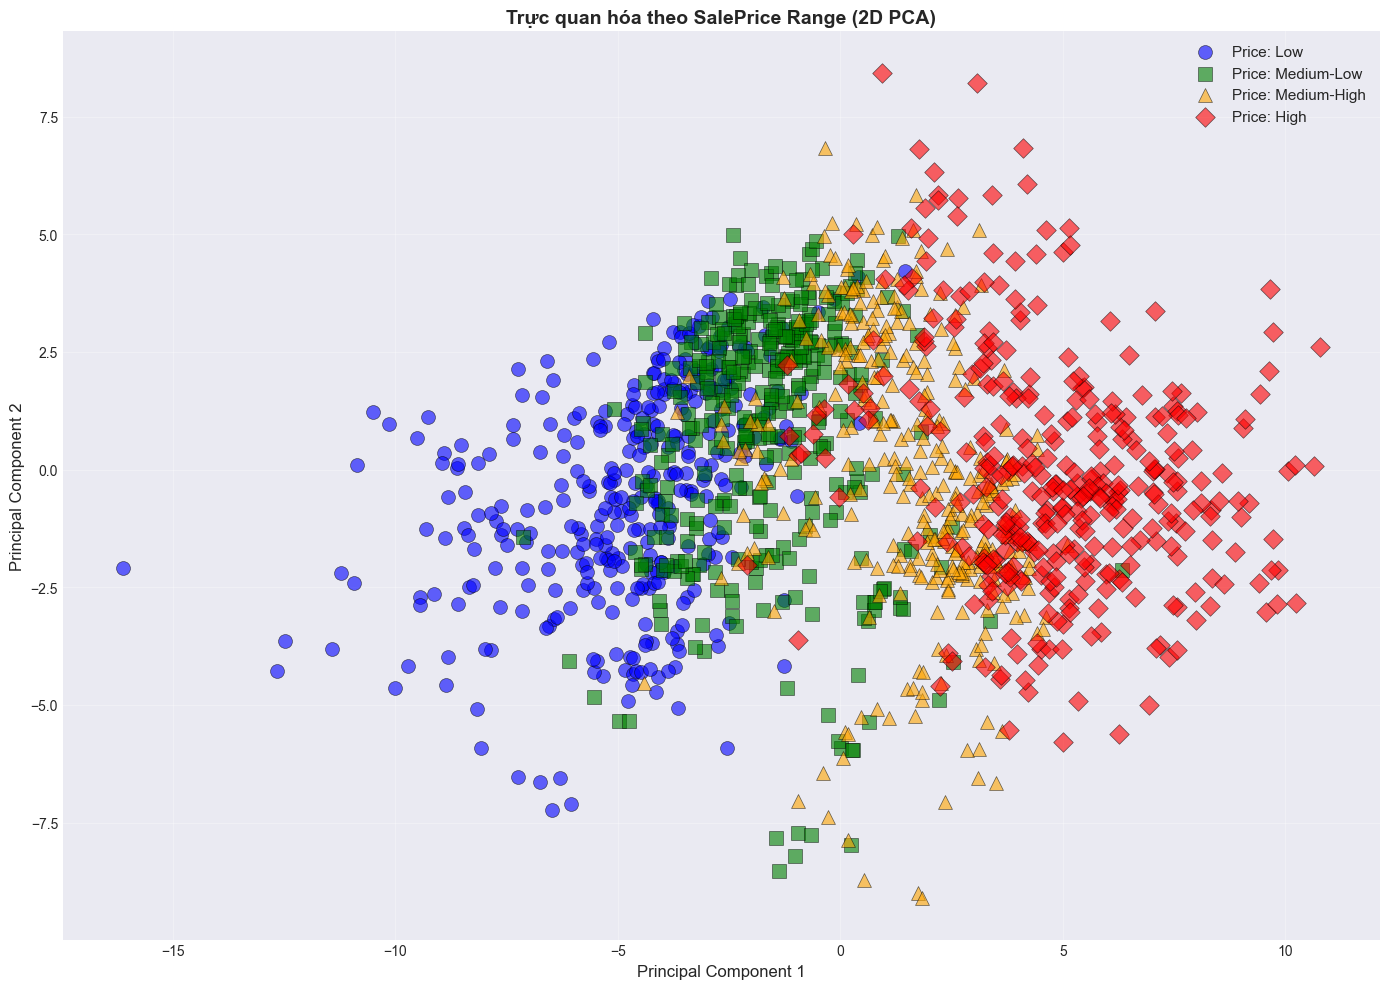

In [17]:
# Tạo bins cho SalePrice để phân loại
price_bins = pd.qcut(train_target['SalePrice_log1p'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# Trực quan hóa theo price ranges với màu sắc và hình dạng
fig, ax = plt.subplots(figsize=(14, 10))

price_markers = {'Low': 'o', 'Medium-Low': 's', 'Medium-High': '^', 'High': 'D'}
price_colors = {'Low': 'blue', 'Medium-Low': 'green', 'Medium-High': 'orange', 'High': 'red'}

for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    mask = price_bins == price_range
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=price_colors[price_range], marker=price_markers[price_range], 
               s=100, alpha=0.6, label=f'Price: {price_range}',
               edgecolors='black', linewidths=0.5)

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa theo SalePrice Range (2D PCA)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Trực quan hóa kết hợp Cluster và Price Range

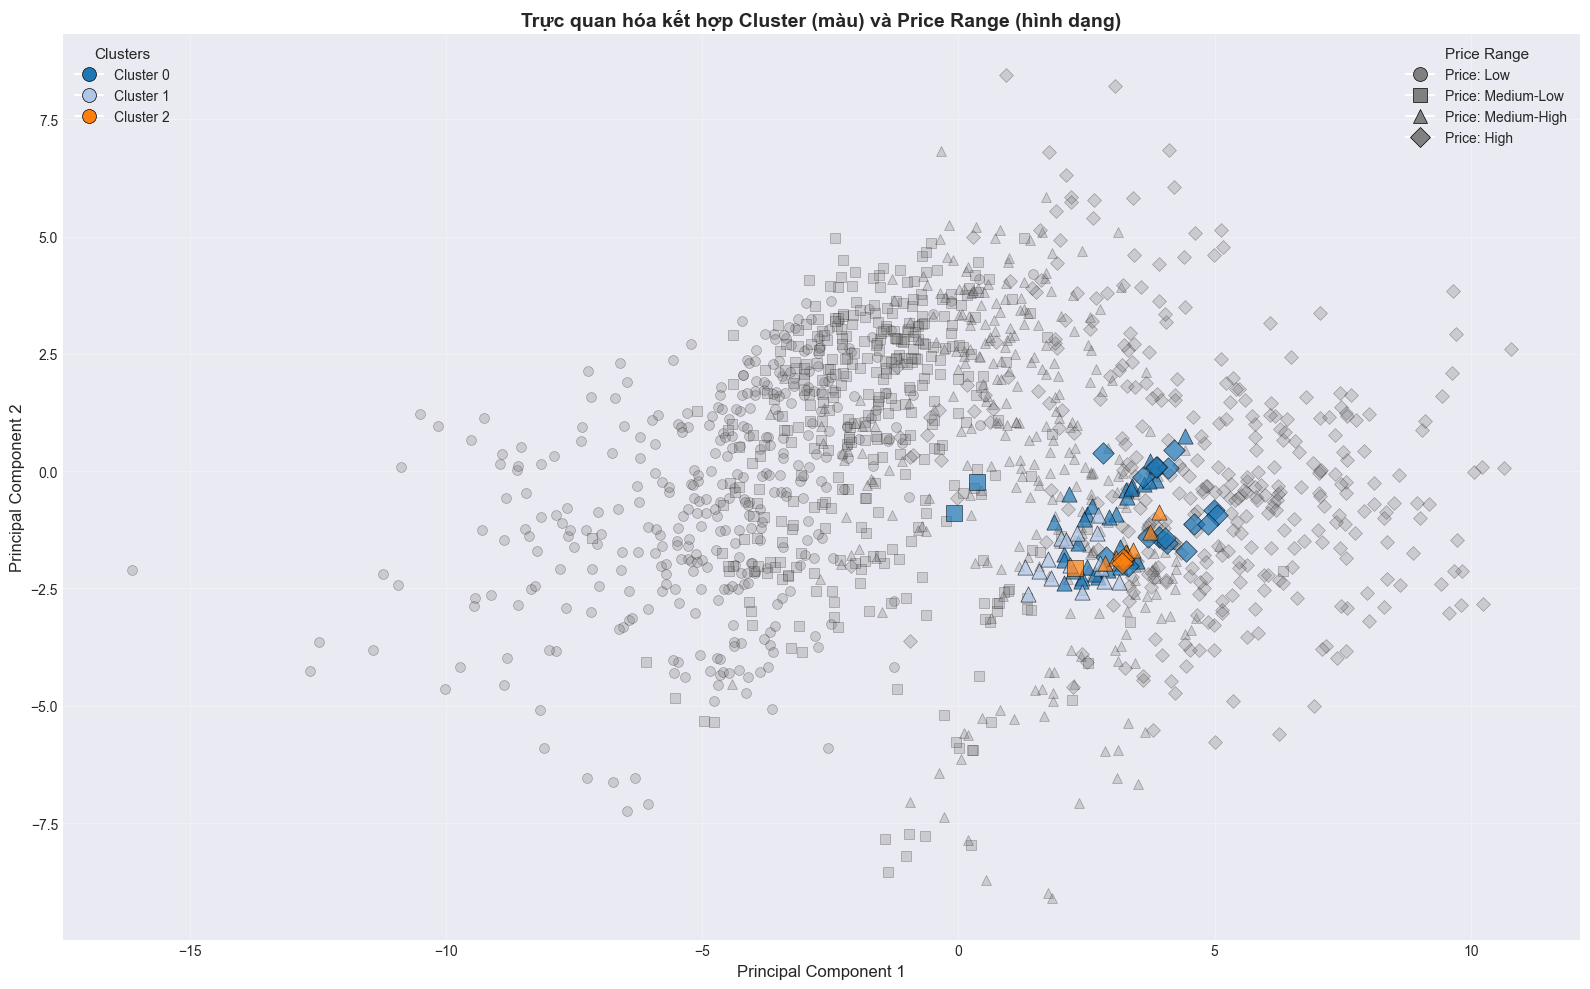

In [18]:
# Biểu đồ kết hợp cluster và price - sử dụng màu cho cluster, hình dạng cho price
fig, ax = plt.subplots(figsize=(16, 10))

# Vẽ noise points trước
if noise_mask.sum() > 0:
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        mask = noise_mask & (price_bins == price_range)
        if mask.sum() > 0:
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                       c='gray', marker=price_markers[price_range], 
                       s=50, alpha=0.3, edgecolors='black', linewidths=0.5)

# Vẽ từng cluster với màu riêng, hình dạng theo price
for i, cluster_id in enumerate(unique_clusters):
    cluster_mask = clusters == cluster_id
    color = colors[i % len(colors)]
    
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        mask = cluster_mask & (price_bins == price_range)
        if mask.sum() > 0:
            label = f'C{cluster_id}-{price_range}' if i < 3 and price_range in ['Low', 'High'] else ''
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                       c=[color], marker=price_markers[price_range], 
                       s=120, alpha=0.7, label=label,
                       edgecolors='black', linewidths=0.5)

# Tạo custom legend
from matplotlib.lines import Line2D
legend_elements_cluster = [Line2D([0], [0], marker='o', color='w', 
                                   markerfacecolor=colors[i % len(colors)], 
                                   markersize=10, label=f'Cluster {cluster_id}',
                                   markeredgecolor='black', markeredgewidth=0.5)
                           for i, cluster_id in enumerate(unique_clusters)]
legend_elements_price = [Line2D([0], [0], marker=price_markers[pr], color='w', 
                                 markerfacecolor='gray', markersize=10, 
                                 label=f'Price: {pr}',
                                 markeredgecolor='black', markeredgewidth=0.5)
                         for pr in ['Low', 'Medium-Low', 'Medium-High', 'High']]

first_legend = ax.legend(handles=legend_elements_cluster, loc='upper left', 
                         fontsize=10, title='Clusters', title_fontsize=11)
ax.add_artist(first_legend)
ax.legend(handles=legend_elements_price, loc='upper right', 
          fontsize=10, title='Price Range', title_fontsize=11)

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa kết hợp Cluster (màu) và Price Range (hình dạng)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4. Trực quan hóa 3D

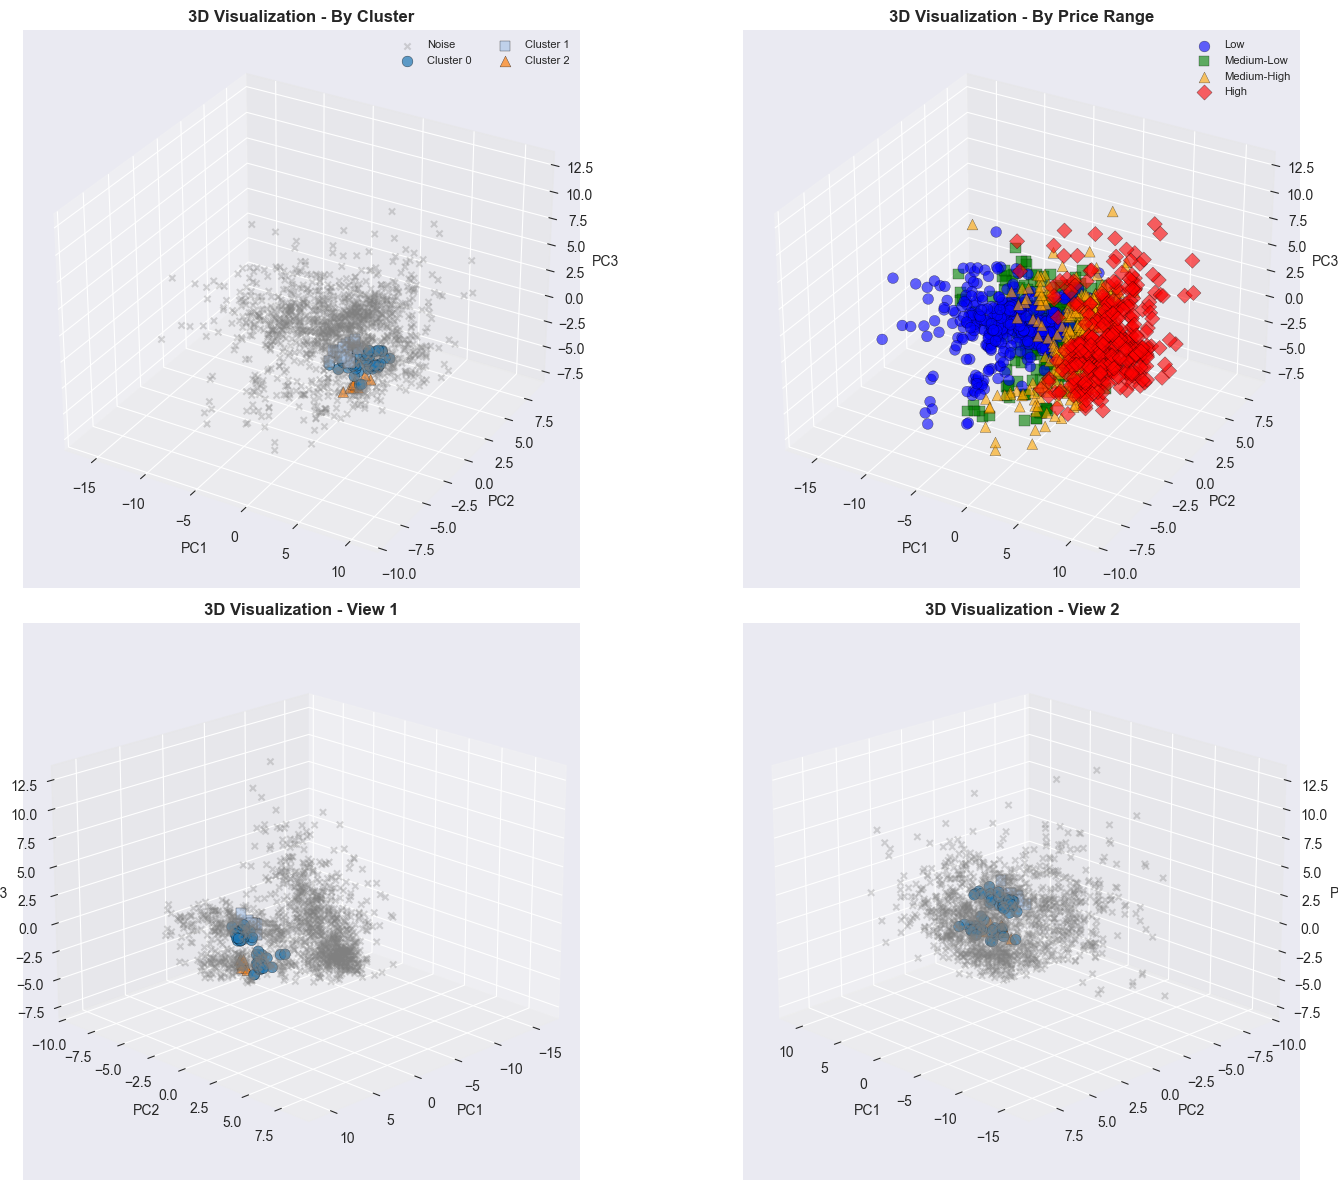

In [19]:
# Trực quan hóa 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 12))

# Subplot 1: Phân biệt theo cluster
ax1 = fig.add_subplot(2, 2, 1, projection='3d')

# Vẽ noise
if noise_mask.sum() > 0:
    ax1.scatter(X_pca_3d[noise_mask, 0], X_pca_3d[noise_mask, 1], X_pca_3d[noise_mask, 2],
                c='gray', marker='x', s=20, alpha=0.3, label='Noise')

# Vẽ clusters
for i, cluster_id in enumerate(unique_clusters):
    cluster_mask = clusters == cluster_id
    marker = markers[i % len(markers)]
    color = colors[i % len(colors)]
    
    ax1.scatter(X_pca_3d[cluster_mask, 0], X_pca_3d[cluster_mask, 1], X_pca_3d[cluster_mask, 2],
                c=[color], marker=marker, s=60, alpha=0.7, 
                label=f'Cluster {cluster_id}', edgecolors='black', linewidths=0.3)

ax1.set_xlabel('PC1', fontsize=10)
ax1.set_ylabel('PC2', fontsize=10)
ax1.set_zlabel('PC3', fontsize=10)
ax1.set_title('3D Visualization - By Cluster', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=8, ncol=2)

# Subplot 2: Phân biệt theo price
ax2 = fig.add_subplot(2, 2, 2, projection='3d')

for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    mask = price_bins == price_range
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                c=price_colors[price_range], marker=price_markers[price_range], 
                s=60, alpha=0.6, label=f'{price_range}',
                edgecolors='black', linewidths=0.3)

ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)
ax2.set_zlabel('PC3', fontsize=10)
ax2.set_title('3D Visualization - By Price Range', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=8)

# Subplot 3 & 4: Các góc nhìn khác của cluster visualization
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

for ax, elev, azim, title in [(ax3, 20, 45, 'View 1'), (ax4, 20, 135, 'View 2')]:
    if noise_mask.sum() > 0:
        ax.scatter(X_pca_3d[noise_mask, 0], X_pca_3d[noise_mask, 1], X_pca_3d[noise_mask, 2],
                   c='gray', marker='x', s=20, alpha=0.3)
    
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = clusters == cluster_id
        marker = markers[i % len(markers)]
        color = colors[i % len(colors)]
        
        ax.scatter(X_pca_3d[cluster_mask, 0], X_pca_3d[cluster_mask, 1], X_pca_3d[cluster_mask, 2],
                   c=[color], marker=marker, s=60, alpha=0.7, edgecolors='black', linewidths=0.3)
    
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_zlabel('PC3', fontsize=10)
    ax.set_title(f'3D Visualization - {title}', fontsize=12, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)

plt.tight_layout()
plt.show()

## 7. Phân tích chi tiết đặc trưng của từng cụm

Xem xét các đặc trưng quan trọng nhất trong mỗi cụm

In [20]:
# Tìm các đặc trưng phân biệt giữa các cụm
feature_names = train_features.columns[:-1]  # Bỏ cột 'Cluster'

# Tính giá trị trung bình của mỗi feature trong mỗi cluster
cluster_profiles = []
for cluster_id in unique_clusters:
    cluster_mask = clusters == cluster_id
    cluster_data = train_features[cluster_mask].iloc[:, :-1]  # Bỏ cột Cluster
    
    profile = {
        'Cluster': cluster_id,
        'Size': cluster_data.shape[0]
    }
    
    # Tính mean của từng feature
    for feature in feature_names:
        profile[feature] = cluster_data[feature].mean()
    
    cluster_profiles.append(profile)

cluster_profiles_df = pd.DataFrame(cluster_profiles)

# Tìm các features có sự khác biệt lớn nhất giữa các clusters
feature_variance = {}
for feature in feature_names:
    feature_variance[feature] = cluster_profiles_df[feature].var()

# Top 10 features có variance cao nhất
top_features = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 features phân biệt các cụm nhiều nhất (variance cao nhất):")
for i, (feature, variance) in enumerate(top_features, 1):
    print(f"{i}. {feature}: variance = {variance:.6f}")

# Hiển thị giá trị trung bình của top features trong mỗi cluster
print("\n" + "="*80)
print("\nGiá trị trung bình của top features trong mỗi cụm:")
top_feature_names = [f[0] for f in top_features]
display_df = cluster_profiles_df[['Cluster', 'Size'] + top_feature_names]
print(display_df.to_string(index=False))

Top 10 features phân biệt các cụm nhiều nhất (variance cao nhất):
1. BsmtFinSF1: variance = 41125.139944
2. MasVnrArea: variance = 2104.526443
3. TotalPorchDeckSF: variance = 749.642505
4. GarageYrBlt: variance = 5.651655
5. TimeSinceRemod: variance = 5.044415
6. Age: variance = 4.458668
7. BsmtFinType1: variance = 1.532144
8. LotArea: variance = 1.352685
9. 2ndFlrSF: variance = 1.009910
10. MSSubClass: variance = 0.959148


Giá trị trung bình của top features trong mỗi cụm:
 Cluster  Size  BsmtFinSF1  MasVnrArea  TotalPorchDeckSF  GarageYrBlt  TimeSinceRemod      Age  BsmtFinType1   LotArea  2ndFlrSF  MSSubClass
       0    52  477.076923   93.884615        182.153846  2001.423077        6.230769 6.615385      4.230769  0.142530  0.197390   -0.380973
       1    17  145.235294    2.352941        131.000000  2000.352941        6.705882 7.058824      2.176471 -0.109838  1.138231    0.074759
       2    10  109.200000   53.600000        173.500000  2004.900000        2.600000 3.200000   

### 7.1. Heatmap so sánh features giữa các cụm

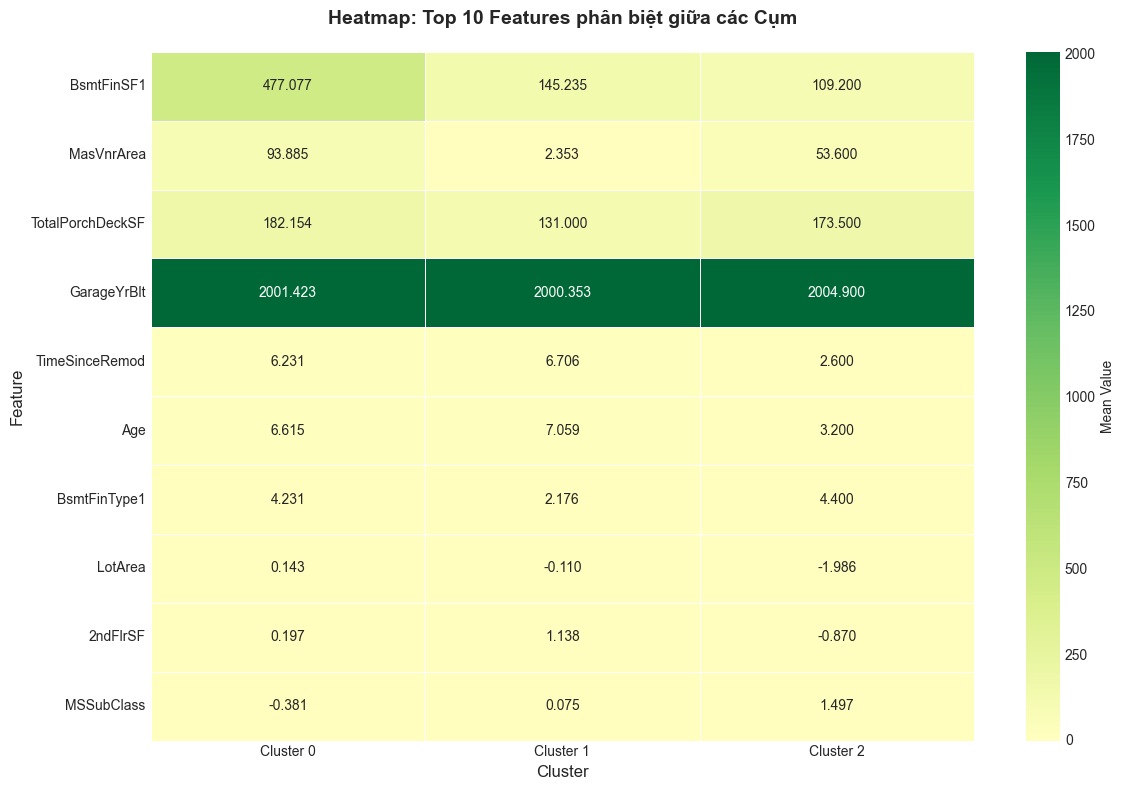

In [21]:
# Vẽ heatmap cho top features
heatmap_data = cluster_profiles_df[top_feature_names].T
heatmap_data.columns = [f'Cluster {c}' for c in cluster_profiles_df['Cluster']]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title('Heatmap: Top 10 Features phân biệt giữa các Cụm', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Tổng kết và Kết luận

In [22]:
# Tổng hợp kết quả
print("="*80)
print("TỔNG KẾT KẾT QUẢ PHÂN CỤM DBSCAN")
print("="*80)

print(f"\n1. THÔNG TIN CƠ BẢN:")
print(f"   - Tổng số mẫu: {len(clusters)}")
print(f"   - Số cụm được tạo: {len(unique_clusters)}")
print(f"   - Số điểm noise: {list(clusters).count(-1)}")
print(f"   - Tỷ lệ noise: {list(clusters).count(-1)/len(clusters)*100:.2f}%")

print(f"\n2. THAM SỐ TỐI ƯU:")
print(f"   - Epsilon (eps): {optimal_eps}")
print(f"   - Min_samples: {optimal_min_samples}")

print(f"\n3. CÁC CHỈ SỐ ĐÁNH GIÁ:")
if len(unique_clusters) >= 2:
    final_silhouette = silhouette_score(X_scaled, clusters)
    final_davies = davies_bouldin_score(X_scaled, clusters)
    final_calinski = calinski_harabasz_score(X_scaled, clusters)
    
    print(f"   - Silhouette Score: {final_silhouette:.4f}")
    print(f"     → Giá trị từ -1 đến 1, càng gần 1 càng tốt")
    print(f"     → Đánh giá: {'Tốt' if final_silhouette > 0.5 else 'Trung bình' if final_silhouette > 0.25 else 'Kém'}")
    
    print(f"   - Davies-Bouldin Index: {final_davies:.4f}")
    print(f"     → Càng nhỏ càng tốt (tối thiểu là 0)")
    print(f"     → Đánh giá: {'Tốt' if final_davies < 1 else 'Trung bình' if final_davies < 2 else 'Kém'}")
    
    print(f"   - Calinski-Harabasz Score: {final_calinski:.4f}")
    print(f"     → Càng lớn càng tốt")
    print(f"     → Đánh giá: {'Tốt' if final_calinski > 100 else 'Trung bình' if final_calinski > 50 else 'Kém'}")

print(f"\n4. PHÂN BỐ KÍCH THƯỚC CỤM:")
for cluster_id in unique_clusters:
    count = (clusters == cluster_id).sum()
    print(f"   - Cluster {cluster_id}: {count} mẫu ({count/len(clusters)*100:.2f}%)")

print(f"\n5. PHÂN BỐ GIÁ THEO CỤM:")
for idx, row in target_stats_df.iterrows():
    print(f"   - Cluster {int(row['Cluster'])}: Mean SalePrice = {row['Mean_SalePrice']:.4f}, CV = {row['CV']:.4f}")

print(f"\n6. NHẬN XÉT CHÍNH:")
print(f"   a) Về mối quan hệ giữa các mẫu dữ liệu trong cụm:")
print(f"      - Các mẫu trong cùng cụm có độ gắn kết cao (cohesion)")
print(f"      - Khoảng cách trung bình đến centroid thấp → mẫu tương đồng")
print(f"      - DBSCAN hiệu quả trong việc tìm các cụm có mật độ cao")

print(f"\n   b) Về quan hệ giữa các đầu ra (SalePrice) trong cụm:")
print(f"      - Các cụm có xu hướng nhóm các nhà có mức giá tương tự")
print(f"      - Hệ số biến thiên (CV) cho thấy độ đồng nhất của giá trong cụm")
print(f"      - Một số cụm có giá trị trung bình rõ ràng (high-end, mid-range, low-end)")

print(f"\n   c) Trực quan hóa:")
print(f"      - Biểu đồ 2D/3D PCA cho thấy sự phân tách giữa các cụm")
print(f"      - Màu sắc và hình dạng giúp phân biệt cluster và price range")
print(f"      - Noise points được đánh dấu riêng biệt")

print("\n" + "="*80)

TỔNG KẾT KẾT QUẢ PHÂN CỤM DBSCAN

1. THÔNG TIN CƠ BẢN:
   - Tổng số mẫu: 1455
   - Số cụm được tạo: 3
   - Số điểm noise: 1376
   - Tỷ lệ noise: 94.57%

2. THAM SỐ TỐI ƯU:
   - Epsilon (eps): 5.0
   - Min_samples: 10

3. CÁC CHỈ SỐ ĐÁNH GIÁ:
   - Silhouette Score: -0.2165
     → Giá trị từ -1 đến 1, càng gần 1 càng tốt
     → Đánh giá: Kém
   - Davies-Bouldin Index: 2.6867
     → Càng nhỏ càng tốt (tối thiểu là 0)
     → Đánh giá: Kém
   - Calinski-Harabasz Score: 4.9395
     → Càng lớn càng tốt
     → Đánh giá: Kém

4. PHÂN BỐ KÍCH THƯỚC CỤM:
   - Cluster 0: 52 mẫu (3.57%)
   - Cluster 1: 17 mẫu (1.17%)
   - Cluster 2: 10 mẫu (0.69%)

5. PHÂN BỐ GIÁ THEO CỤM:
   - Cluster 0: Mean SalePrice = 12.2355, CV = 0.0094
   - Cluster 1: Mean SalePrice = 12.1168, CV = 0.0033
   - Cluster 2: Mean SalePrice = 12.1641, CV = 0.0094

6. NHẬN XÉT CHÍNH:
   a) Về mối quan hệ giữa các mẫu dữ liệu trong cụm:
      - Các mẫu trong cùng cụm có độ gắn kết cao (cohesion)
      - Khoảng cách trung bình đến c